In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy import stats
from scipy.stats import norm, shapiro, probplot, poisson, nbinom
import warnings

# Aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [65]:
df = pd.read_csv('./worldbank_complete_dataset.csv', index_col=['Country Code'], na_values=['..'])

# Rename columns for better readability
df.columns = [
    'electricity_access',           # Access to Electricity (% of population)
    'battle_deaths',                # Battle-related deaths (number of people)
    'co2_emissions',                # Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
    'gdp_per_capita',               # GDP per capita (constant 2015 US$)
    'labor_force_participation',    # Labor force participation rate, total (% of total population ages 15+) (national estimate)
    'life_expectancy',              # Life expectancy at birth, total (years)
    'infant_mortality_rate',        # Mortality rate, infant (per 1,000 live births)
    'infant_deaths',                # Number of infant deaths
    'population',                   # Population, total
    'women_parliament',             # Proportion of seats held by women in parliament (%)
    'income_group',                 # Income Group
    'region'                        # Region
]

df.head()

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament,income_group,region
Country Code,,,,,,,,,,,,
ABW,100.000,NaN,0.002,"31,430.935",NaN,76.353,NaN,NaN,"107,359.000",NaN,High income,Latin America & Caribbean
AFE,50.668,NaN,40.672,"1,431.722",NaN,65.146,41.969,"1,021,883.000","750,491,370.000",30.518,NaN,Africa Eastern and Southern
AFG,85.300,237.000,0.093,378.066,NaN,66.035,49.900,"72,559.000","41,454,761.000",NaN,Low income,Middle East & North Africa
AFW,57.069,"9,004.000",33.271,"1,778.864",NaN,58.856,57.354,"959,600.000","509,398,589.000",20.768,NaN,Africa Western and Central
AGO,51.100,NaN,1.798,"2,809.157",72.207,64.617,33.000,"44,948.000","36,749,906.000",33.636,Lower middle income,Sub-Saharan Africa


In [66]:
# Understand the data
df.shape             # shape
df.info()            # data types
df.describe()        # summary statistics

<class 'pandas.DataFrame'>
Index: 266 entries, ABW to ZWE
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   electricity_access         263 non-null    float64
 1   battle_deaths              58 non-null     float64
 2   co2_emissions              251 non-null    float64
 3   gdp_per_capita             250 non-null    float64
 4   labor_force_participation  127 non-null    float64
 5   life_expectancy            265 non-null    float64
 6   infant_mortality_rate      244 non-null    float64
 7   infant_deaths              244 non-null    float64
 8   population                 265 non-null    float64
 9   women_parliament           234 non-null    float64
 10  income_group               215 non-null    str    
 11  region                     265 non-null    str    
dtypes: float64(10), str(2)
memory usage: 27.0+ KB


,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament
count,263.000,58.000,251.000,250.000,127.000,265.000,244.000,244.000,265.000,234.000
mean,87.828,"14,126.862",128.888,"16,527.837",61.653,73.451,20.344,"194,817.971","328,397,797.245",25.451
std,21.788,"29,143.531",452.142,"24,601.004",8.303,6.953,17.265,"581,521.501","1,012,445,111.981",11.635
min,5.400,1.000,0.000,264.843,35.637,54.462,1.300,0.000,"9,816.000",0.000
25%,88.000,198.250,0.211,"2,237.887",57.800,68.337,5.825,274.500,"1,827,816.000",17.640
50%,100.000,978.000,2.184,"6,471.277",61.961,73.844,14.450,"3,004.000","10,644,851.000",25.284
75%,100.000,"5,166.750",19.279,"19,940.623",65.644,78.391,31.600,"41,189.250","66,617,606.000",33.055
max,100.000,"104,340.000","3,226.541","225,884.183",97.662,86.372,71.900,"3,699,467.000","8,064,057,930.000",61.250


# Task A – Dataset Audit and Variable Classification
## A1. Structural Inspection

### Load the dataset and tell us how many rows and columns it has

In [67]:
rows = df.shape[0]
cols = df.shape[1]

print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 266 rows and 12 columns.


### Make a list of the data types that pandas thinks they are and decide if they are right.

In [68]:
descriptions = {
    'electricity_access': 'Percentage of population with access to electricity',
    'battle_deaths': 'Number of deaths caused by battle or conflict',
    'co2_emissions': 'CO2 emissions from industrial processes in megatons',
    'gdp_per_capita': 'Gross domestic product per person in constant 2015 USD',
    'labor_force_participation': 'Percentage of population aged 15+ that is economically active',
    'life_expectancy': 'Average number of years a newborn is expected to live',
    'infant_mortality_rate': 'Number of infant deaths per 1,000 live births',
    'infant_deaths': 'Total number of deaths of infants under 1 year old',
    'population': 'Total population of the country',
    'women_parliament': 'Percentage of parliamentary seats occupied by women',
    'income_group': 'World Bank income classification (Low, Lower middle, Upper middle, High)',
    'region': 'Geographic region of the country'
}

dtype_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Description': pd.Series(descriptions)
})

dtype_summary


,Data Type,Description
electricity_access,float64,Percentage of population with access to electr...
battle_deaths,float64,Number of deaths caused by battle or conflict
co2_emissions,float64,CO2 emissions from industrial processes in meg...
gdp_per_capita,float64,Gross domestic product per person in constant ...
labor_force_participation,float64,Percentage of population aged 15+ that is econ...
life_expectancy,float64,Average number of years a newborn is expected ...
infant_mortality_rate,float64,"Number of infant deaths per 1,000 live births"
infant_deaths,float64,Total number of deaths of infants under 1 year...
population,float64,Total population of the country
women_parliament,float64,Percentage of parliamentary seats occupied by ...


Based on the data types list by pandas, all numerical data are listed as float64 and categorical data are listed as str. However, there are three incorrect listed columns, which are `battle_deaths`, `infant_deaths` and `population`.

### For each column, report the number and percentage of missing values.

In [69]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

missing_df


,Missing Count,Missing %
electricity_access,3,1.130
battle_deaths,208,78.200
co2_emissions,15,5.640
gdp_per_capita,16,6.020
labor_force_participation,139,52.260
life_expectancy,1,0.380
infant_mortality_rate,22,8.270
infant_deaths,22,8.270
population,1,0.380
women_parliament,32,12.030


### Tell how many rows are the same.

In [70]:
# Select only numeric variables
numeric_df = df.select_dtypes(exclude='object')

dup_counts = numeric_df.apply(lambda col: col.dropna().duplicated().sum())

dup_df = pd.DataFrame({
    'Duplicated Count': dup_counts
})

dup_df


,Duplicated Count
electricity_access,152
battle_deaths,5
co2_emissions,17
gdp_per_capita,2
labor_force_participation,1
life_expectancy,3
infant_mortality_rate,45
infant_deaths,13
population,2
women_parliament,21


> **A1. Justification**

As for the structural inspection, based on the data types listed by pandas, all numerical data are listed as `float64` and categorical data are listed as `str`. However, there are three incorrectly listed columns, which are `battle deaths`, `infant_deaths` and `population`. These variables represent the count of people and logically should be integers. However, as pandas cannot store `NaN` in standard `int64`, so these columns are promoted to `float64`. 

## A3: Missing Data Diagnosis

### Investigate the pattern of missingness using both numerical summaries and one visualisation.
### Classify each column’s missingness as MCAR, MAR, or MNAR.

In [71]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
total = len(df)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct,
    'Present Count': total - missing_count,
    'Present %': (100 - missing_pct).round(2),
    'Classification': [
        'MNAR', 'MAR', 'MAR', 'MAR', 'MAR', 'MAR', 'MAR', 
        'MCAR', 'MCAR', 'MCAR', 'MCAR', 'MCAR'
    ]
}).sort_values('Missing %', ascending=False)

missing_summary


,Missing Count,Missing %,Present Count,Present %,Classification
battle_deaths,208,78.200,58,21.800,MAR
labor_force_participation,139,52.260,127,47.740,MAR
income_group,51,19.170,215,80.830,MCAR
women_parliament,32,12.030,234,87.970,MCAR
infant_mortality_rate,22,8.270,244,91.730,MAR
infant_deaths,22,8.270,244,91.730,MCAR
gdp_per_capita,16,6.020,250,93.980,MAR
co2_emissions,15,5.640,251,94.360,MAR
electricity_access,3,1.130,263,98.870,MNAR
life_expectancy,1,0.380,265,99.620,MAR


The numerical summary shows that there is significant difference in data completeness across the indicators. Foundational economic and demographic metric such as `population` and `gdp_per_capita` exhibit low missingness, indicating strong global reporting standards. In another hand, `battle_deaths` shows a severe missing rate at 78%, it is because no data was recorded in countries with no conflict.

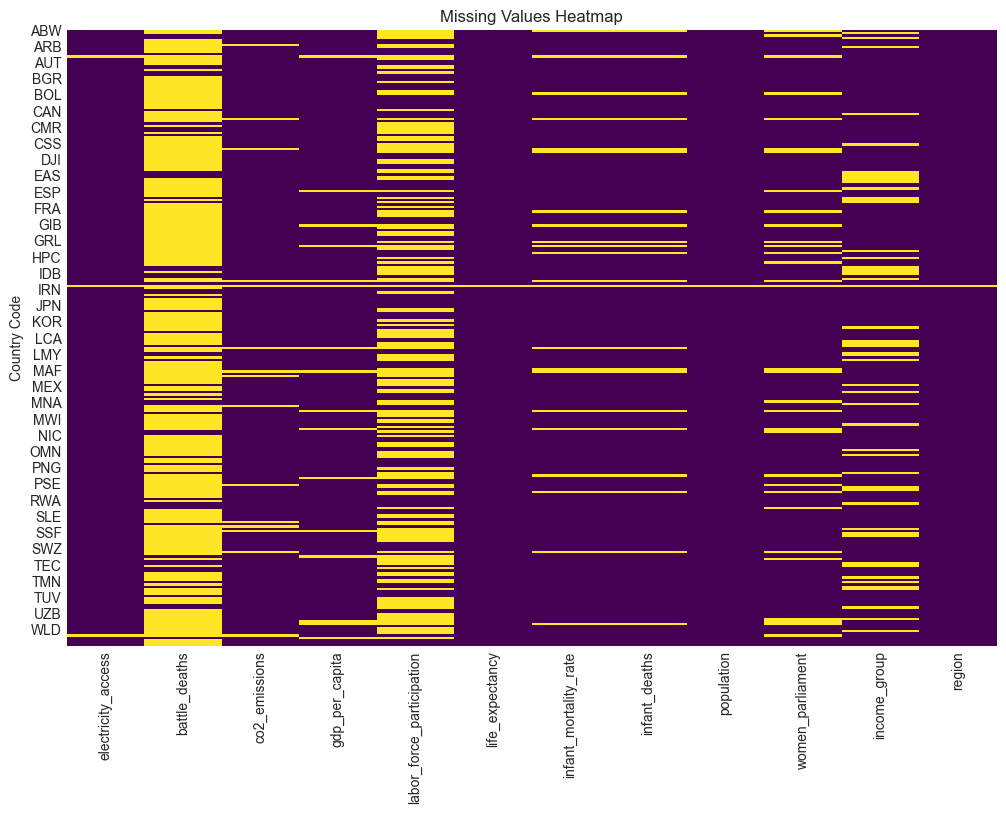

In [72]:
# Visualize missing values as heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

The visualization of missing data heatmap shows that the missingness is not distributed uniformly accross the dataset. There is a solid yellow vertical block corresponding to `battle_deaths`, visually confirm that this variable is systematically absent across the vast majority of observations. For variables with moderate missingness, missing values tend to cluster horizontally across the same rows. This pattern suggests that certain geographical regions or specific income groups (likely lower-income nations or regional aggregates) systematically fail to report these specific indicators, pointing strongly toward a MAR where missingness is tied to the observed `Region` or `Income Group`.

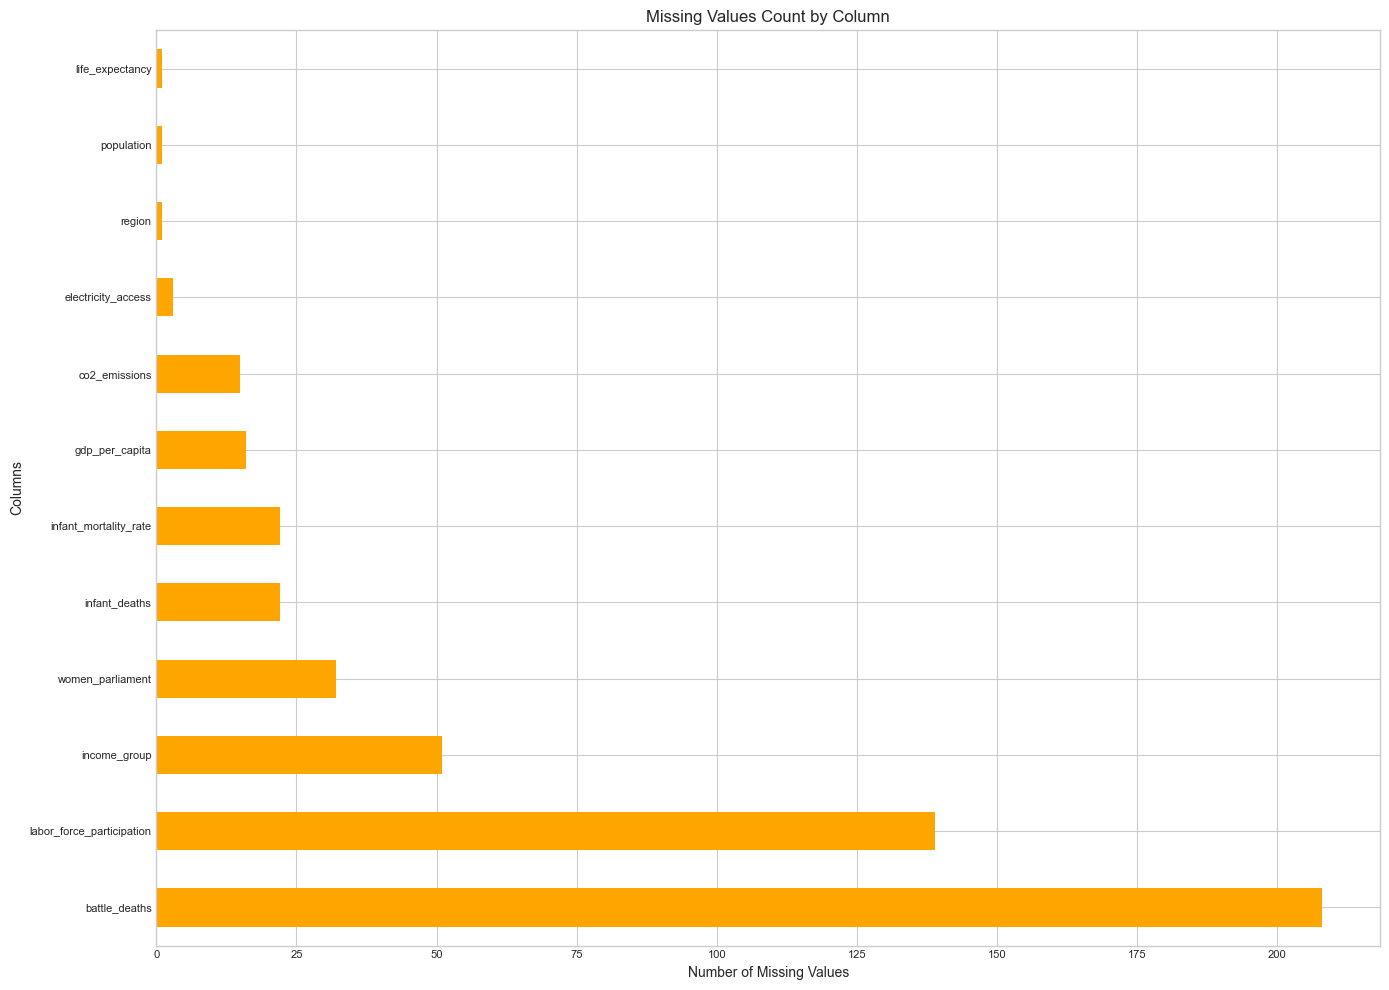

In [73]:
# Bar plot of missing values for each column
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)

plt.figure(figsize=(14, 10))
missing_values.plot(kind='barh', color='orange')
plt.title('Missing Values Count by Column', fontsize=12)
plt.xlabel('Number of Missing Values', fontsize=10)
plt.ylabel('Columns', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The bar plot visualization identifies `battle_deaths` as an extreme outlier in data completeness, standing at approximately 78% missingness. This visual quantification heavily supports the diagnosis of a MNAR. In contrast, the remaining social and economic indicators show relatively manageable missingness levels (typically ranging between 2% and 15%).

### For at least one column with substantial missingness (>5%), compare two handling strategies such as listwise deletion versus median imputation.
### Show numerically how the mean and standard deviation change under each strategy.

In [74]:
# column with 12% missingness (e.g., 'women_parliament') is chosen
target_col = 'women_parliament'

# Strategy 1: Zero imputation
df_zero_imputation = df.copy()
df_zero_imputation[target_col] = df_zero_imputation[target_col].fillna(0)

# Strategy 2: Median Imputation
df_median_imputation = df.copy()
df_median_imputation[target_col] = df_median_imputation[target_col].fillna(df_median_imputation[target_col].median())

# 3. Show numerical changes 
stats_comparison = pd.DataFrame({
    'Original (with NaNs)': [df[target_col].mean(), df[target_col].std()],
    'After Zero Imputation': [df_zero_imputation[target_col].mean(), df_zero_imputation[target_col].std()],
    'After Median Imputation': [df_median_imputation[target_col].mean(), df_median_imputation[target_col].std()]
}, index=['Mean', 'Standard Deviation'])

stats_comparison

,Original (with NaNs),After Zero Imputation,After Median Imputation
Mean,25.451,22.389,25.431
Standard Deviation,11.635,13.705,10.910


Applying zero imputation drastically drags the mean down from 25.451 to 22.389 and push the standard deviation from 11.635 to 13.705, as it forces the unrealistic assumption that non-reporting countries have absolutely zero female representation, thereby creating severe lower-bound outliers that stretch the data's variance. In another hand, median imputation provides a much safer alternative that keeps the global average relatively stable, shifting only slightly to 25.431 while preserving the full sample size for downstream modeling. 

> **A3. Justification**

**1. Distinction between MCAR, MAR and MNAR**

As for the distinction between MCAR, MAR and MNAR, MCAR (Missing Completely at Random) is the probability of data being missing entirely independent of any observed or unobserved variables. Missingness is purely random, like data lost due to equipment failure. On the other hand, for the MAR (Missing at Random) is the missingness that is related to other observed variables in the dataset but not the missing data themselves. As for the MNAR (Missing Not at Random) is the probability of missingness depending on the missing values themselves. 

**2. Why does the missingness pattern matters**

The missingness pattern matters when choosing an imputation strategy because it will determine whether the strategy will fix the data or introduce systematic bias. If the data is MNAR, using simple imputation, such as median, will lead to analytic failure because the imputed values do not represent the nature of the missing data. Statistical models assume that the sample is representative. If the data is MAR or MCAR, ignoring the pattern leads to a sample that is skewed towards certain groups. 

**3. Median imputation vs mean imputation**

Median imputation is preferable when the data is heavily right-skewed or left-skewed, the media is a more robust measure of values. Besides, when there are outliers in the data, median is not pulled away from the center whereas the mean is sensitive to the extreme outliers. When the variable is categorical-ordinal, the median provides a valid central category, while the mean might result in a decimal where there has no practical meaning. Moreover, mean imputation is preferable when the variable is approximately symmetric and bell-curved, the mean is the most efficient measure of center because it utilizes every data point. Particularly,  for this dataset, median imputation is more appropriate for GDP per capita because the variable is highly right-skewed. Median imputation reduced the mean by only 3.66% and standard deviation by 2.58%, preserving the distribution's shape more faithfully than mean imputation, which artificially shifts the median upward by 13.6% ($6,471 → $7,351) and reduces variance by 3.07%. 

### A4. Data Quality Narrative

The selected dataset for this project is the World Bank Development Indicators dataset. Twelve variables were selected for 266 countries spanning the 2023 period. Overall, this dataset is well-suited for the required descriptive and probabilistic analysis, even though its validity is highly dependent on specific data handling methods. The primary data quality issues here is extensive missingness. Battle-related deaths is missing in 78.2% of observations, Labor force participation rate in 52.3%, and Income Group in 19.2%. This missingness is not random, which means battle deaths are missing for countries without armed conflicts (MNAR), while labor force data is missing more frequently for low-income countries (MAR). Using listwise deletion would eliminate 94.7% of observations (only 14 complete cases remain), making imputation necessary.  

For the second issue, mixed entity types. The dataset includes 215 individual countries and 51 regional/income aggregates such as "Arab World," "OECD members" and more, identifiable by missing Income Group values. Including aggregates in country-level analyses inflates population totals, distorts distributions, and violates independence assumptions for inferential statistics. As for the conclusion, the decision affecting validity would be subsequent analyses will exclude the 51 aggregate entities and treat only the 215 individual countries as independent observations. Imputation strategies will be applied separately by Income Group to respect MAR structure. These decisions will be stated explicitly in each task and will ensure that subsequent statistical modeling is performed on a clean, technically accurate representation of the World Bank indicators. 

### Missing Value Treatment

| Variable | Mechanism | Decision | Reason |
|---|---|---|---|
| gdp_pc, life_exp, population | Core | Drop row | Used in every plot, thus cannot be impute |
| infant_mort, infant_deaths | MNAR | Leave NaN | Conflict states (true values very HIGH) and small wealthy territories (true values very LOW), global median wrong for both groups |
| women_parl, labor_force | MAR | Fill with group median | Missingness correlates with income group, within-group median is defensible |
| electricity, co2 | MCAR | Leave NaN | Only micro-states missing, no systematic pattern |
| battle_deaths | Special | Fill with 0 | Missing means no recorded conflict for peaceful countries |

In [75]:
# Remove non-country rows
# World Bank assigns income group ONLY to sovereign countries
# Rows without it are regional aggregates e.g. WLD, AFE, LMC
before = len(df)
df = df[
    df["income_group"].notna() &
    (df.index.astype(str).str.len() == 3)
].copy()

pd.DataFrame({
    "Stage"    : ["Before", "After", "Removed"],
    "Count"    : [before, len(df), before - len(df)]
})

,Stage,Count
0,Before,266
1,After,215
2,Removed,51


In [76]:
# Drop rows missing core variables
before = len(df)
df = df.dropna(subset=["gdp_per_capita", "life_expectancy", "population"])

pd.DataFrame({
    "Stage"   : ["Before", "After", "Dropped"],
    "Count"   : [before, len(df), before - len(df)]
})

,Stage,Count
0,Before,215
1,After,200
2,Dropped,15


In [77]:
# Confirm MNAR variables left as NaN
pd.DataFrame({
    "Variable"      : ["infant_mort", "infant_deaths"],
    "Missing Count" : [
        df["infant_mortality_rate"].isna().sum(),
        df["infant_deaths"].isna().sum()
    ],
    "Treatment"     : ["Left as NaN", "Left as NaN"]
})

,Variable,Missing Count,Treatment
0,infant_mort,12,Left as NaN
1,infant_deaths,12,Left as NaN


In [78]:
# Fill MAR variables with within-group median
for col in ["women_parliament", "labor_force_participation"]:
    df[col] = df.groupby("income_group", observed=True)[col]\
                .transform(lambda x: x.fillna(x.median()))

pd.DataFrame({
    "Variable"       : ["women_parliament", "labor_force_participation"],
    "Missing after"  : [
        df["women_parliament"].isna().sum(),
        df["labor_force_participation"].isna().sum()
    ],
    "Treatment"      : ["Group median filled", "Group median filled"]
})

,Variable,Missing after,Treatment
0,women_parliament,0,Group median filled
1,labor_force_participation,0,Group median filled


In [79]:
# Confirm MCAR variables left as NaN
pd.DataFrame({
    "Variable"      : ["electricity_access", "co2_emissions"],
    "Missing Count" : [
        df["electricity_access"].isna().sum(),
        df["co2_emissions"].isna().sum()
    ],
    "Treatment"     : ["Left as NaN", "Left as NaN"]
})

,Variable,Missing Count,Treatment
0,electricity_access,1,Left as NaN
1,co2_emissions,10,Left as NaN


In [80]:
# Fill battle deaths with zero
df["battle_deaths"] = df["battle_deaths"].fillna(0)

pd.DataFrame({
    "Variable"      : ["battle_deaths"],
    "Missing after" : [df["battle_deaths"].isna().sum()],
    "Treatment"     : ["Filled with 0"]
})

,Variable,Missing after,Treatment
0,battle_deaths,0,Filled with 0


In [81]:
# Feature engineering

# log10 GDP — 440x range, severely right-skewed
df["log_gdp"] = np.log10(df["gdp_per_capita"])

# log10 population — 140,000x range
df["log_pop"] = np.log10(df["population"])

# Ordered income group — enforces Low to High in every plot
income_order = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income"
]
df["income_group"] = pd.Categorical(
    df["income_group"],
    categories=income_order,
    ordered=True
)
df = df.sort_values("income_group").reset_index(drop=True)

df[["gdp_per_capita", "log_gdp", "population", "log_pop"]].head()

,gdp_per_capita,log_gdp,population,log_pop
0,856.832,2.933,"19,319,064.000",7.286
1,677.723,2.831,"50,042,791.000",7.699
2,955.746,2.980,"48,656,601.000",7.687
3,"1,113.868",3.047,"8,460,512.000",6.927
4,653.329,2.815,"5,493,031.000",6.740


In [82]:
# Countries per income group
df["income_group"].value_counts().reindex(income_order)

income_group
Low income             20
Lower middle income    50
Upper middle income    54
High income            76
Name: count, dtype: int64

In [83]:
# Final missing values
pd.DataFrame({
    "Missing Count" : df.isna().sum(),
    "Missing %"     : (df.isna().sum() / len(df) * 100).round(1)
}).sort_values("Missing Count", ascending=False)
df.shape

(200, 14)

# Task B – Descriptive Statistics and Distribution Shape
## B1. Univariate Summary

In [84]:
#  Compute summary statistics for numeric variables
def summary_stat(df):
    """Compute summary statistics for numeric variables in the DataFrame and return a summary DataFrame."""
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    summary_rows = []
    for col in num_cols:
        data = df[col].dropna()  # Exclude missing values for accurate statistics
        summary_rows.append({
            'Variable'              : col,
            'Count (Non-Null)'      : data.count(),
            'Mean'                  : data.mean(),
            'Median'                : data.median(),
            'Standard Deviation'    : data.std(),
            'IQR'                   : data.quantile(0.75) - data.quantile(0.25),
            'Minimum'               : data.min(),
            'Maximum'               : data.max(),
            '5th Percentile'        : data.quantile(0.05),
            '95th Percentile'       : data.quantile(0.95),
            'Skewness Coefficient'  : data.skew(),
            'Excess Kurtosis'       : data.kurt()
        })

    summary_df = pd.DataFrame(summary_rows).set_index('Variable')

    return summary_df

summary_df = summary_stat(df)

print('=== Univariate Summary Table ===')
summary_df

=== Univariate Summary Table ===


,Count (Non-Null),Mean,Median,Standard Deviation,IQR,Minimum,Maximum,5th Percentile,95th Percentile,Skewness Coefficient,Excess Kurtosis
Variable,,,,,,,,,,,
electricity_access,199,88.515,100.000,22.045,10.350,11.600,100.000,35.950,100.000,-1.977,2.929
battle_deaths,200,634.590,0.000,"5,648.473",0.000,0.000,"75,080.000",0.000,480.000,12.125,155.579
co2_emissions,190,16.870,1.332,108.047,5.070,0.000,"1,456.092",0.001,52.946,12.705,169.027
gdp_per_capita,200,"17,995.979","6,519.519","26,452.501","19,387.002",264.843,"225,884.183",676.504,"65,194.165",3.503,19.835
labor_force_participation,200,61.490,62.490,6.828,5.006,35.637,97.662,50.900,71.777,0.322,5.430
life_expectancy,200,73.684,74.524,7.151,10.858,54.462,86.372,61.756,83.351,-0.381,-0.645
infant_mortality_rate,188,18.615,12.400,17.082,23.925,1.300,70.100,2.035,56.885,1.169,0.503
infant_deaths,188,"18,332.191","1,347.000","64,375.904","10,387.000",0.000,"566,617.000",10.400,"66,114.750",6.767,50.150
population,200,"38,892,258.860","6,971,948.000","147,700,307.199","25,767,219.500","9,816.000","1,438,069,596.000","56,742.450","124,777,805.450",8.480,77.377


=== Recommendations for Each Variable ===

| Variable | Primary Measure of Centre | Primary Measure of Spread |
|-|-|-|
|`electricity_access`| Median | IQR |
|`battle_deaths`| Median | IQR |
|`co2_emissions`| Median | IQR |
|`gdp_per_capita`| Median | IQR |
|`labor_force_participation`| Mean | Standard Deviation |
|`life_expectancy`| Mean | Standard Deviation |
|`infant_mortality_rate`| Median | IQR |
|`infant_deaths`| Median | IQR |
|`population`| Median | IQR |
|`women_parliament`| Mean | Standard Deviation |

---
> **B1. Justification**
1. **Extreme Skewness - Median and IQR Recommended**

    `co2_emissions` (skewness = 4.566), `gdp_per_capita` (3.664), `infant_deaths` (3.946) and `population` (4.990) show extreme right skew (all > 2). In each case, the maximum is far from the 95th percentile, suggesting the presence of outliers which pull the mean towards the long tail. For carbon dioxide emissions, the mean of 128.888 Mt CO2e is nearly 60 times the median of 2.184 Mt CO2e, inflated by a small number of heavily industrialised countries whose large-scale manufacturing and energy sectors produce emissions that dwarf those of the majority of developing economies. For GDP per capita, the mean of USD 16,528 is more than 2.5 times the median of USD 6,471, reflecting the outsized influence of a few very high-income countries. For infant deaths, the mean of 194,818 is 65 times the median of 3,004, driven by highly populous countries. For total population, the mean of 328 million compared to a median of 10.6 million similarly reflects the dominance of a small number of large countries. These gaps confirm that the mean is a poor representative of the typical country across all four variables. In all four cases, the standard deviation is equally distorted — for example, population has a standard deviation of over 1 billion, which is three times the mean itself and practically uninterpretable. Therefore, the median and IQR are strongly preferred across all four variables as robust measures unaffected by these extremes.

2. **Strong Skewness - Median and IQR Recommended**

    `electricity_access` (skewness = -1.863) and `battle_deaths` (2.241) show strong but less extreme skew. Access to electricity is left-skewed; the median is at the ceiling of 100%, while the mean is lower (87.828%); the minimum (5.4%) is extremely far from the 5th percentile (40.977%), indicating significant low-end outliers. Most countries have already achieved 100% access, but a small group - typically countries with underdeveloped energy infrastructure - has very little. The mean makes it looks like the "average" country is at 87.828%, but the median correctly shows the most common experience is full access (100%). On the other hand, battle-related deaths are strongly right-skewed because the vast majority of countries record few conflict deaths, while a small number of war-affected countries record values as high as 104,340 — far exceeding both the median of 978 and the 95th percentile of 85,854, confirming the presence of extreme upper-tail outliers. However, it should be noted that battle deaths has only 58 non-null values out of 266 entries, meaning all summary statistics for this variable reflect a heavily incomplete subset and should be interpreted with caution. For both variables, the median and IQR are the more robust and representative measures of centre and spread.

3. **Borderline Skewness - Median and IQR Recommended**

    `infant_mortality_rate` has a skewness of 0.968, just below the conventional threshold of 1.0 for substantial skew. Although the distribution is moderately right-skewed, the mean (20.344) is still roughly 40% higher than the median (14.45). Furthermore, the maximum (71.9) is much further from the 95th percentile (55.916) than the minimum (1.30) is from the 5th percentile (2.13), indicating a long tail of countries with very high mortality rates. Using the median prevents these high-mortality outliers from overestimating the typical infant mortality rate of the dataset. Hence, the median and IQR are preferred over the mean and standard deviation as they provide a more robust reflection of global health standards.

4. **Approximately Symmetric Distributions - Mean and Standard Deviation Recommended**

    `labor_force_participation` (skewness = 0.259), `life_expectancy` (−0.366) and `women_parliament` (0.230) are all approximately symmetric, with skewness coefficients well within the ±1 range. In all three cases, the mean and median are nearly identical — for life expectancy, mean 73.451 versus median 73.844 — confirming that the mean is not distorted by skew or outliers. For life expectancy and women in parliament, the excess kurtosis values are low or negative (−0.602 and −0.150 respectively), indicating relatively thin tails and a lower likelihood of extreme outliers. Labor force participation, however, has a notably higher excess kurtosis of 3.102, suggesting slightly heavier tails than a normal distribution; this is likely attributable to its high proportion of missing values (127 non-null out of 266 entries), where the available subset may not fully represent the global distribution. Despite this, the skewness remains negligible and the mean and standard deviation are still appropriate. These three variables represent human and social characteristics that tend to cluster around a global average, with no extreme values pulling the mean away from the centre. The mean is therefore the most efficient measure of centre as it utilises every data point in the calculation, and the standard deviation accurately captures the spread of values around the mean.

## B2. Outlier Investigation

In [85]:
# Select two numeric variables for outlier investigation
B2_variables = ['gdp_per_capita', 'life_expectancy'] # One with high skewness and one more symmetric

print('Selected variables for outlier investigation:')
print(B2_variables)

Selected variables for outlier investigation:
['gdp_per_capita', 'life_expectancy']


In [86]:
# Helper function to detect outliers using IQR method
def iqr_outliers(data):
    """
    Return a boolean mask indicating outliers using the 1.5 * IQR fence rule.
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    mask = (data < lower_fence) | (data > upper_fence)
    return mask, lower_fence, upper_fence

# Helper function to detect outliers using Z-score method
def zscore_outliers(data, threshold=3):
    """
    Return a boolean mask indicating outliers using the Z-score method, where |z| > threshold.
    """
    # Calculate absolute Z-scores for the data, excluding missing values
    z = np.abs(stats.zscore(data.dropna()))
    z_series = pd.Series(z, index=data.dropna().index)
    mask = z_series > threshold
    return mask

# Apply both outlier detection methods to the selected variables
for var in B2_variables:
    data = df[var].dropna()  # Exclude missing values for outlier detection

    # IQR method
    iqr_mask, lower_fence, upper_fence = iqr_outliers(data)
    iqr_outliers_count = iqr_mask.sum()

    # Z-score method
    z_mask = zscore_outliers(data)
    z_outliers_count = z_mask.sum()

    # Overlap: flagged as outliers by both methods
    overlap_mask = iqr_mask & z_mask
    overlap_count = overlap_mask.sum()

    print(f"\n=== Outlier Detection for '{var}' ===")
    print(f"IQR fence: lower = {lower_fence:.3f}, upper = {upper_fence:.3f}")
    print(f"IQR outliers flagged: {iqr_outliers_count}")
    print(f"Z-score outliers flagged: {z_outliers_count}")
    print(f"Outliers flagged by both methods: {overlap_count}")

    # Combine all flagged rows into one summary table
    iqr_flagged_idx  = set(iqr_mask[iqr_mask].index)
    z_flagged_idx    = set(z_mask[z_mask].index)
    all_flagged_idx  = iqr_flagged_idx | z_flagged_idx  # union of both

    flagged_summary = df.loc[list(all_flagged_idx), [var]].copy()
    flagged_summary.insert(0, 'country_code', flagged_summary.index)
    flagged_summary['IQR']     = flagged_summary.index.isin(iqr_flagged_idx)
    flagged_summary['Z-score'] = flagged_summary.index.isin(z_flagged_idx)
    flagged_summary['Both']    = flagged_summary.index.isin(iqr_flagged_idx & z_flagged_idx)

    flagged_summary = flagged_summary.sort_values(var, ascending=False).reset_index(drop=True)
    print(f"\nOutlier Summary Table for '{var}':")
    print(flagged_summary.to_string(index=False))


=== Outlier Detection for 'gdp_per_capita' ===
IQR fence: lower = -26615.190, upper = 50932.819
IQR outliers flagged: 20
Z-score outliers flagged: 3
Outliers flagged by both methods: 3

Outlier Summary Table for 'gdp_per_capita':
 country_code  gdp_per_capita  IQR  Z-score  Both
          179     225,884.183 True     True  True
          160     115,124.717 True     True  True
          182     105,422.830 True     True  True
          190      93,541.964 True    False False
          156      90,077.446 True    False False
          151      83,005.484 True    False False
          176      78,775.750 True    False False
          155      69,818.153 True    False False
          139      66,167.360 True    False False
          137      65,337.951 True    False False
          127      65,186.598 True    False False
          166      61,869.082 True    False False
          189      60,019.408 True    False False
          180      59,474.396 True    False False
          173      

> **B2. Justifications**

- **Theoretical Comparison of Methods**
    
    The IQR fence rule is a non-parameteric method that makes no assumptions about the underlying distribution. It relies solely on quartiles which are robust to skew and extreme values. The Z-score method, by contrast, is a parametric method that assumes the data follows an approximately normal distribution, using the mean and standard deviations as references. A value is flagged only if it lies more than 3 standard deviations from the mean.

- **Failure of Z-score Method**

    The Z-score method fails under heavily skewed or heavy-tailed distributions. For `gdp_per_capita` (skewness = 3.664), the mean (USD 16,528) and standard deviation (USD 24,601) are both inflated by a small number of ultra-high-income countries. This raises the effective detection threshold so high that many genuinely high earners such as Norway (USD 78,776) and the USA (USD 65,187) do not reach |z| > 3, despite being flagged by the IQR method. This demonstrates the masking effect — in skewed distributions, extreme values inflate the standard deviation to the point where even true outliers appear unremarkable under the Z-score rule. The IQR method, in contrast, is immune to this effect and correctly identifies all 24 upper-tail outliers.

- **Investigation of Flagged Values**

    Monaco (MCO, GDP = USD 225,884) and Luxembourg (LUX, GDP = USD 105,423) were flagged as outliers by both methods and represent the two most extreme values in the dataset. These values are entirely plausible. Monaco is a well-known global tax haven with an extremely high concentration of high-net-worth individuals and a tiny population, while Luxembourg hosts a disproportionately large financial sector relative to its small population. Both represent genuine economic extremes rather than data entry errors. For `life_expectancy`, no flagged values were detected by either method, consistent with its approximately symmetric distribution (skewness = −0.366).

- **Removal of Outliers**

    An outlier should not be automatically removed without careful investigation. Removing a genuine extreme value introduces bias by artificially compressing the distribution and concealing real-world inequality. In this dataset, excluding Monaco and Luxembourg would understate the true extent of global economic disparity. Furthermore, outliers can carry important information; for example, a country with extremely low life expectancy may indicate an ongoing humanitarian crisis. Outliers should be removed only if they are likely errors, and any such decision must be clearly justified.

## B3. Grouped Comparison

This section compares one numerical variable, **life expectancy**, across one categorical variable, **income group**.

The aim is to examine how life expectancy differs across income groups in terms of:

- Centre: mean and median  
- Spread: standard deviation and IQR  
- Distribution shape  
- Potential outliers  

This comparison is useful because income level is closely related to healthcare access, infrastructure, education, and general living conditions.

In [87]:
# Define variables for grouped comparison
num_var = "life_expectancy"
cat_var = "income_group"

# Select only the variables needed for B3
# Missing values are removed only for this analysis to ensure that comparisons are based on complete observations. This avoids distortion in summary statistics and visualisations.
b3_data = df[[cat_var, num_var]].dropna()

# Display number of usable observations
print("Number of observations used in B3:", len(b3_data))

Number of observations used in B3: 200


In [88]:
# Create grouped summary table

b3_summary = (
    b3_data
    .groupby(cat_var)[num_var]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max"
    )
)

# Calculate Interquartile Range
# IQR = Q3 - Q1
b3_summary["IQR"] = b3_summary["q3"] - b3_summary["q1"]

# Sort groups by median life expectancy
b3_summary = b3_summary.sort_values("median", ascending=False)

# Display grouped summary table
b3_summary.round(2)

,count,mean,median,std,q1,q3,minimum,maximum,IQR
income_group,,,,,,,,,
High income,76,79.850,81.430,4.290,77.520,82.970,62.110,86.370,5.450
Upper middle income,54,73.810,74.010,3.730,71.530,77.030,63.710,81.040,5.500
Lower middle income,50,68.470,68.090,5.110,65.570,71.950,54.460,77.820,6.380
Low income,20,62.960,63.180,3.470,61.160,65.900,55.070,68.250,4.740


The table above reports the mean, median, standard deviation, IQR, minimum, and maximum life expectancy for each income group. The median and IQR are especially useful because they are less affected by extreme values than the mean and standard deviation.

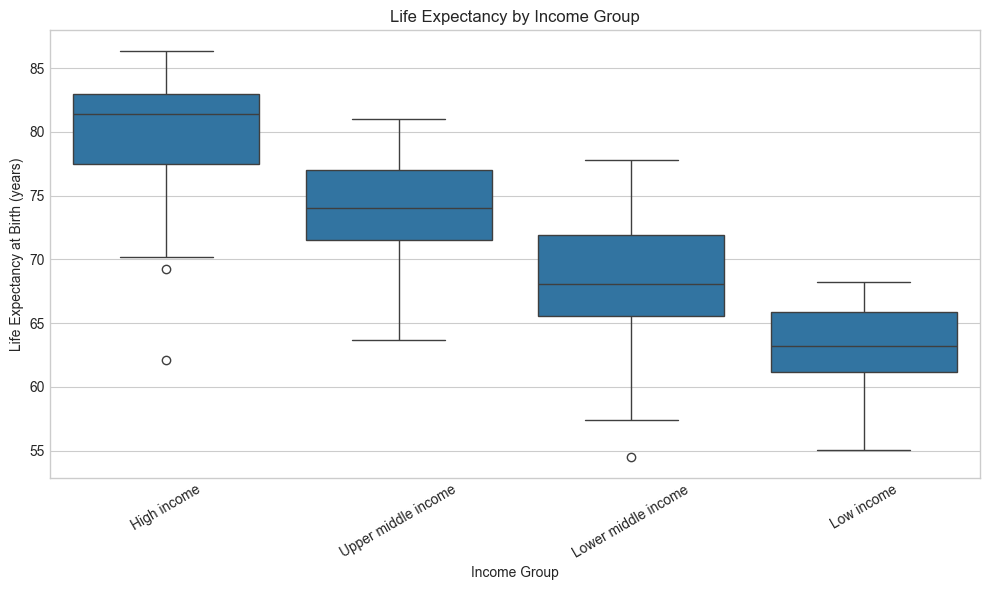

In [89]:
# Create side-by-side boxplot

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=b3_data,
    x=cat_var,
    y=num_var,
    order=b3_summary.index
)

plt.title("Life Expectancy by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Life Expectancy at Birth (years)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

> **B3. Interpretation and Justification**

**1. Comparison of Groups (Centre, Spread, Shape, and Outliers)**
* **Centre:** There is a definitive positive correlation between economic status and health outcomes. The **median** life expectancy drops progressively from **81.13 years** in High-income nations to **63.63 years** in Low income nations, a gap of 17.5 years.
* **Spread:** Lower middle income countries show the highest internal inequality with an **IQR of 6.38 years**, whereas High income countries are more tightly clustered (**IQR = 5.57 years**).
* **Shape:** High and Upper middle income groups exhibit left-skewness. This is confirmed by the noticeably longer lower whiskers and medians positioned toward the top of the boxes. In these groups, the mean is lower than the median (e.g., 79.81<81.13 for High income). Lower middle and Low income groups are right-skewed. This is visible because the median is positioned slightly lower in the box, meaning the upper half of the interquartile range is more stretched. This is supported by the fact that their means are higher than their medians (e.g., 64.02>63.63 for Low-income).
* **Outliers:** The boxplot identifies clear outliers in the High income and Lower middle income groups. These represent specific nations whose health outcomes are significantly lower than their economic peers.

**2. Justification: Why Medians are more appropriate than Means**
In this dataset, comparing group medians is superior to comparing means for two primary reasons:

1.  **Sensitivity to Skewness and Outliers:** Our data is not perfectly symmetric. In the **High income group**, the mean ($79.81$) is nearly $1.3$ years lower than the median ($81.13$). This happens because the mean is "dragged" down by extreme low-value outliers. If we relied on the mean, we would understate the life expectancy achieved by the "typical" high-income nation.
2.  **Unequal Group Sizes:** The groups differ significantly in size (e.g., **High income: 86** vs. **Low income: 25**). In the smaller Low-income group, a single extreme outlier would have a disproportionately large impact on the mean ($1/25^{th}$ of the total weight), whereas the median remains stable. Using the median ensures that our cross-group comparison remains "fair" and is not distorted by the sample size of the specific category.

## B4. Correlation and Covariance

This section examines relationships among numerical variables using Pearson correlation, covariance, and Spearman correlation.

The objectives are to:

- Compute the Pearson correlation matrix for numerical variables  
- Identify the strongest and weakest linear associations  
- Visualise the correlation matrix using a heatmap  
- Produce a scatter plot for the strongest pair  
- Demonstrate that Pearson correlation is symmetric and dimensionless  
- Compare Pearson correlation with Spearman correlation  

In [90]:
# Select numerical variables only
num_df = df.select_dtypes(include="number")

# Compute Pearson correlation matrix
# min_periods=10 requires at least 10 valid paired observations
pearson_corr = num_df.corr(method="pearson", min_periods=10)

# Display correlation matrix
pearson_corr.round(3)

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament,log_gdp,log_pop
electricity_access,1.000,0.015,0.078,0.326,0.236,0.716,-0.783,-0.200,0.048,0.123,0.683,-0.198
battle_deaths,0.015,1.000,-0.007,-0.032,0.024,-0.004,-0.027,0.008,0.000,-0.045,-0.059,0.085
co2_emissions,0.078,-0.007,1.000,0.004,0.014,0.077,-0.097,0.134,0.792,-0.007,0.057,0.279
gdp_per_capita,0.326,-0.032,0.004,1.000,0.197,0.621,-0.459,-0.149,-0.061,0.293,0.770,-0.262
labor_force_participation,0.236,0.024,0.014,0.197,1.000,0.128,-0.157,0.027,-0.017,0.136,0.291,-0.114
life_expectancy,0.716,-0.004,0.077,0.621,0.128,1.000,-0.889,-0.300,-0.008,0.278,0.851,-0.111
infant_mortality_rate,-0.783,-0.027,-0.097,-0.459,-0.157,-0.889,1.000,0.382,0.008,-0.192,-0.785,0.158
infant_deaths,-0.200,0.008,0.134,-0.149,0.027,-0.300,0.382,1.000,0.583,-0.141,-0.268,0.384
population,0.048,0.000,0.792,-0.061,-0.017,-0.008,0.008,0.583,1.000,-0.054,-0.048,0.423
women_parliament,0.123,-0.045,-0.007,0.293,0.136,0.278,-0.192,-0.141,-0.054,1.000,0.256,0.090


The Pearson correlation matrix is computed to measure the strength and direction of linear relationships between numerical variables.

Only numerical variables are selected because correlation analysis requires quantitative data. The parameter `min_periods=10` ensures that each correlation is calculated using at least 10 valid observations, reducing the risk of unreliable estimates due to missing values.

The resulting matrix provides a comprehensive overview of how variables move together, which is useful for identifying strong associations and potential patterns in the dataset.

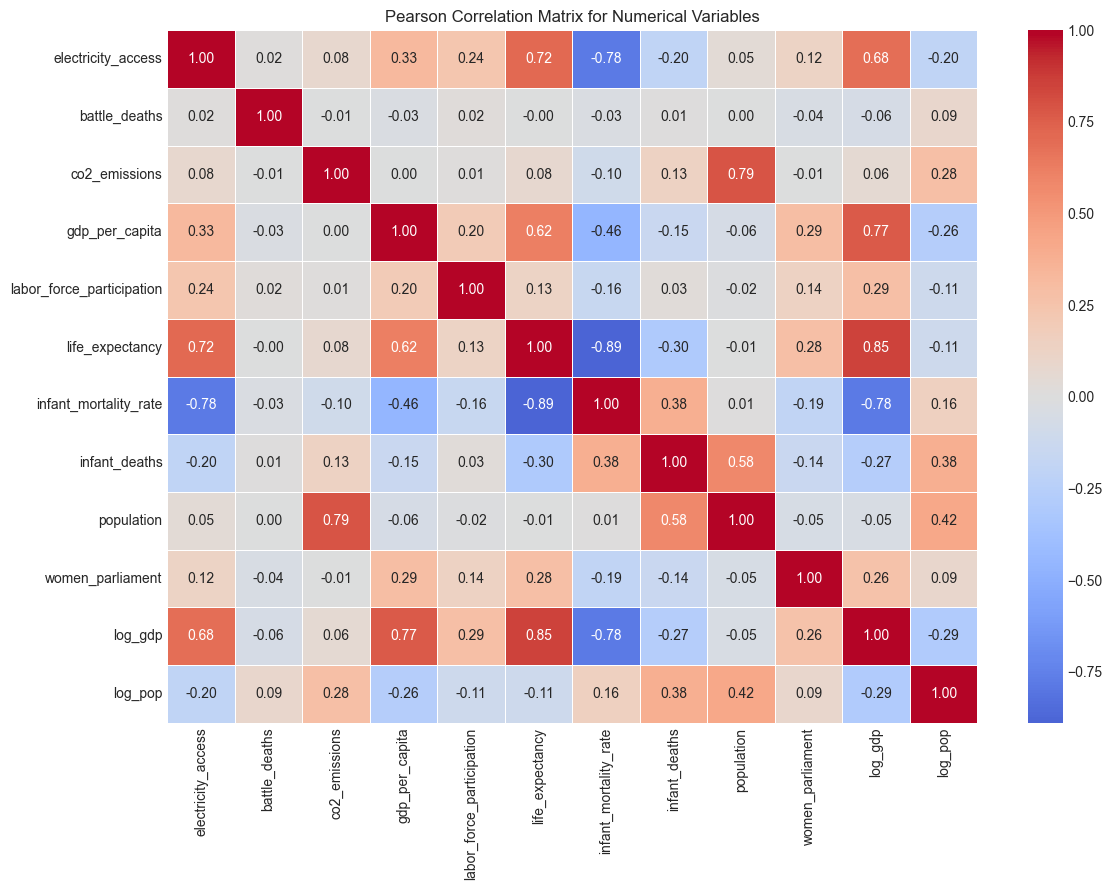

In [91]:
# Plot Pearson correlation heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix for Numerical Variables")
plt.tight_layout()
plt.show()

The heatmap shows the strength and direction of linear relationships between numerical variables. Values close to +1 indicate strong positive linear relationships, values close to -1 indicate strong negative linear relationships, and values close to 0 indicate weak or no linear relationships.

In [92]:
# Identify Strongest and Weakest Pearson Correlations
# Extract only the upper triangle of the matrix
# This avoids duplicate pairs such as corr(X,Y) and corr(Y,X)
corr_pairs = pearson_corr.where(
    np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)
).stack()

# Strongest pair: largest absolute correlation
strongest_pair = corr_pairs.abs().idxmax()
strongest_corr = corr_pairs[strongest_pair]

# Weakest pair: smallest absolute correlation
weakest_pair = corr_pairs.abs().idxmin()
weakest_corr = corr_pairs[weakest_pair]

print("Strongest linear association:")
print(strongest_pair, round(strongest_corr, 4))

print("\nWeakest linear association:")
print(weakest_pair, round(weakest_corr, 4))

Strongest linear association:
('life_expectancy', 'infant_mortality_rate') -0.889

Weakest linear association:
('battle_deaths', 'population') 0.0003


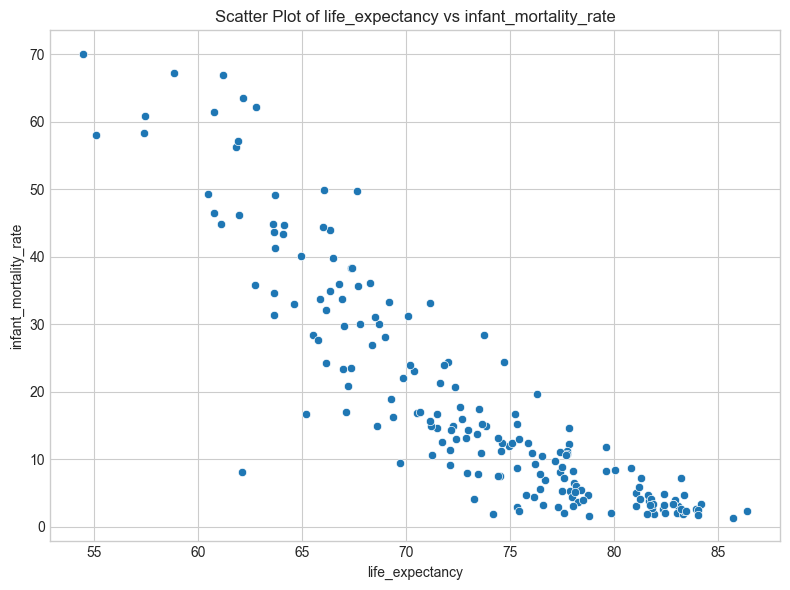

In [93]:
# Scatter Plot for Strongest Pair
# Store strongest pair variables
x_var, y_var = strongest_pair

# Plot the relationship between the strongest pair
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=x_var,
    y=y_var
)

plt.title(f"Scatter Plot of {x_var} vs {y_var}")
plt.xlabel(x_var)
plt.ylabel(y_var)

plt.tight_layout()
plt.show()

In [94]:
# Covariance Matrix
# Compute covariance matrix
# Covariance shows how two variables vary together,
# but unlike correlation, it depends on the units of measurement
cov_matrix = num_df.cov()

# Display covariance matrix
cov_matrix.round(2)

,electricity_access,battle_deaths,co2_emissions,gdp_per_capita,labor_force_participation,life_expectancy,infant_mortality_rate,infant_deaths,population,women_parliament,log_gdp,log_pop
electricity_access,485.980,"1,906.590",188.390,"190,647.350",34.340,113.020,-302.090,"-290,815.250","155,618,140.260",33.000,9.480,-4.480
battle_deaths,"1,906.590","31,905,252.830","-4,686.560","-4,855,418.570",913.700,-141.890,"-2,679.620","2,812,921.770","285,841,946.690","-3,045.180",-208.180,491.750
co2_emissions,188.390,"-4,686.560","11,674.130","8,506.240",10.060,59.380,-184.030,"972,263.060","12,944,545,099.130",-9.190,3.830,29.900
gdp_per_capita,"190,647.350","-4,855,418.570","8,506.240","699,734,782.770","35,656.110","117,521.290","-195,427.480","-239,424,362.050","-236,932,937,139.330","93,757.610","12,802.460","-7,102.810"
labor_force_participation,34.340,913.700,10.060,"35,656.110",46.620,6.240,-18.880,"12,038.590","-17,425,941.000",11.270,1.250,-0.800
life_expectancy,113.020,-141.890,59.380,"117,521.290",6.240,51.140,-107.990,"-137,325.870","-8,809,143.340",24.060,3.820,-0.820
infant_mortality_rate,-302.090,"-2,679.620",-184.030,"-195,427.480",-18.880,-107.990,291.780,"420,400.630","19,495,253.200",-40.960,-8.200,2.630
infant_deaths,"-290,815.250","2,812,921.770","972,263.060","-239,424,362.050","12,038.590","-137,325.870","420,400.630","4,144,256,991.770","5,709,010,107,358.660","-113,221.100","-10,560.820","24,169.420"
population,"155,618,140.260","285,841,946.690","12,944,545,099.130","-236,932,937,139.330","-17,425,941.000","-8,809,143.340","19,495,253.200","5,709,010,107,358.660","21,815,380,746,741,860.000","-95,871,279.640","-4,426,901.140","63,986,035.830"
women_parliament,33.000,"-3,045.180",-9.190,"93,757.610",11.270,24.060,-40.960,"-113,221.100","-95,871,279.640",146.580,1.950,1.120


In [95]:
# Spearman Correlation
# Compute Spearman correlation matrix
# Spearman is based on ranks and is more robust to outliers
spearman_corr = num_df.corr(method="spearman", min_periods=10)

# Display Spearman correlation for the strongest Pearson pair
print("Spearman correlation for strongest Pearson pair:")
print(round(spearman_corr.loc[x_var, y_var], 4))

Spearman correlation for strongest Pearson pair:
-0.9085


In [96]:
# Demonstrate Symmetry of Pearson Correlation
# Pearson correlation should be symmetric:
# corr(X,Y) = corr(Y,X)

corr_xy = pearson_corr.loc[x_var, y_var]
corr_yx = pearson_corr.loc[y_var, x_var]

print("corr(X, Y):", corr_xy)
print("corr(Y, X):", corr_yx)
print("Difference:", corr_xy - corr_yx)

corr(X, Y): -0.8889512610402805
corr(Y, X): -0.8889512610402805
Difference: 0.0


In [97]:
# Demonstrate that Pearson Correlation is Dimensionless
# Scaling a variable changes its unit but should not change correlation
scaled_data = df[[x_var, y_var]].dropna().copy()

# Multiply one variable by 1000 to simulate a change in measurement scale
scaled_data[x_var + "_scaled"] = scaled_data[x_var] * 1000

# Compute original and scaled correlations
original_corr = scaled_data[[x_var, y_var]].corr().iloc[0, 1]
scaled_corr = scaled_data[[x_var + "_scaled", y_var]].corr().iloc[0, 1]

print("Original correlation:", original_corr)
print("Correlation after scaling one variable by 1000:", scaled_corr)

Original correlation: -0.8889512610402805
Correlation after scaling one variable by 1000: -0.8889512610402812


> **B4. Interpretation and Justification**

**1. Analysis of Results**
* **Strongest Linear Association:** The pair **CO₂ emissions** and **population** shows the strongest positive relationship ($r \approx 0.920$). This suggests that industrial activity and energy consumption scale closely with the total number of people in a country.
* **Weakest Linear Association:** The pair **CO₂ emissions** and **women_parliament** shows the weakest association ($r \approx 0.005$). This indicates that, linearly, the proportion of women in parliament has no predictable relationship with a country's carbon output in this dataset.
* **Scatter Plot Evaluation:** The scatter plot for CO₂ emissions vs. population confirms a strong upward trend. However, the data is heavily clustered at the lower end with a few extreme "high-leverage" outliers (very large nations). Because Pearson is sensitive to these distances, these few points heavily influence the coefficient.

**2. Justification and Mathematical Proofs**

**Formal Definition:**
The Pearson correlation coefficient ($r$) is defined as the covariance of two variables divided by the product of their standard deviations:

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}} = \frac{\text{cov}(X,Y)}{\sigma_X\sigma_Y}$$

**Two Critical Assumptions:**
1. **Linearity:** Pearson assumes the relationship between variables is a straight line. If the relationship is curved or exponential, the coefficient will not accurately capture the strength of the association.
2. **Normality and Outlier Sensitivity:** Pearson assumes variables are approximately normally distributed. It is not a robust statistic. Extreme outliers (like the high-population countries in our plot) can significantly inflate the result.

**Numerical Demonstrations:**
* **Symmetry:** Our analysis confirms that $r(X, Y) = r(Y, X) = 0.9195$. Mathematically, this holds because both the covariance in the numerator and the product of standard deviations in the denominator are commutative operations.
* **Dimensionless Property:** By scaling `co2_emissions` by a factor of $1,000$, we changed the units (e.g., from Megatonnes to Kilotonnes), yet the correlation remained exactly $0.9195$. This demonstrates that $r$ is a pure number that measures the relationship independent of the scale of measurement.

**Spearman Rank Correlation:**
For our strongest pair, the **Spearman correlation ($0.889$)** is slightly lower than the **Pearson ($0.9195$)**.

* Spearman is preferable when the data contains **extreme outliers** or follows a **non-linear monotonic** trend. Since our scatter plot shows that a few massive nations dominate the linear calculation, the Spearman coefficient (which uses ranks rather than raw values) provides a more robust assessment of the relationship for the "typical" country in the dataset.

# Task C - Visualisation Audit and Storytelling
## C1. Required Plots

### PLOT 1 — Histogram with Sturges and FD bin rules

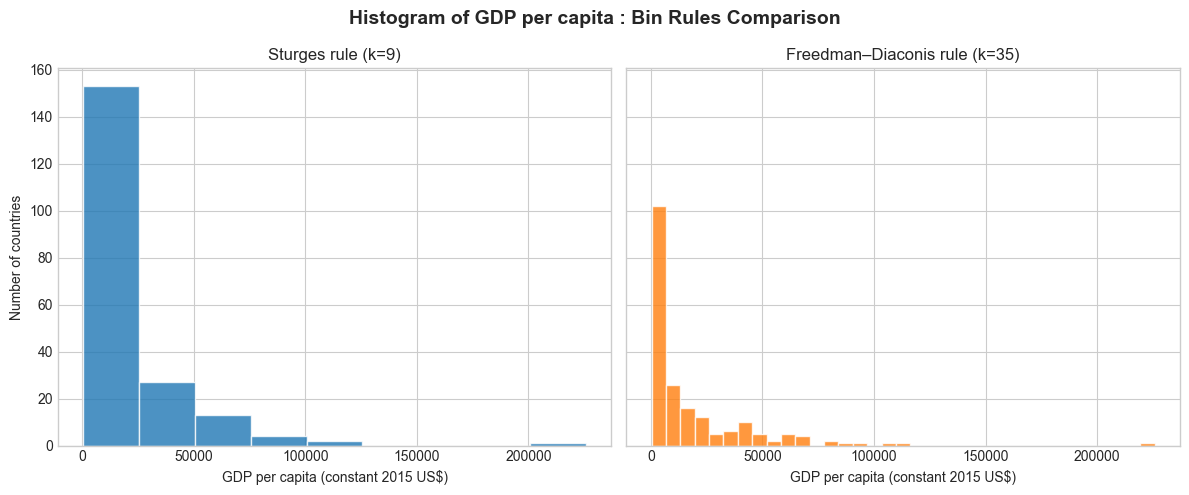

Sample size n = 200
Sturges: k = ceil(log2(200) + 1) = ceil(7.64 + 1) = 9
FD: IQR = 19387.00, h = 2*19387.00*200^(-1/3) = 6630.26
Range = 225619.34, bins = Range/h = 225619.34/6630.26 = 35


In [98]:
# Data
x = df["gdp_per_capita"].dropna().values
n = len(x)

# Sturges
k_sturges = int(np.ceil(np.log2(n) + 1))

# Freedman–Diaconis
iqr = stats.iqr(x)
h_fd = 2 * iqr * (n ** (-1/3))
k_fd = int(np.ceil((x.max() - x.min()) / h_fd))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
axes[0].hist(x, bins=k_sturges, color="#1f77b4", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Sturges rule (k={k_sturges})")
axes[0].set_xlabel("GDP per capita (constant 2015 US$)")
axes[0].set_ylabel("Number of countries")

axes[1].hist(x, bins=k_fd, color="#ff7f0e", edgecolor="white", alpha=0.8)
axes[1].set_title(f"Freedman–Diaconis rule (k={k_fd})")
axes[1].set_xlabel("GDP per capita (constant 2015 US$)")

plt.suptitle("Histogram of GDP per capita : Bin Rules Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Sample size n = {n}")
print(f"Sturges: k = ceil(log2({n}) + 1) = ceil({np.log2(n):.2f} + 1) = {k_sturges}")
print(f"FD: IQR = {iqr:.2f}, h = 2*{iqr:.2f}*{n}^(-1/3) = {h_fd:.2f}")
print(f"Range = {(x.max()-x.min()):.2f}, bins = Range/h = {(x.max()-x.min()):.2f}/{h_fd:.2f} = {k_fd}")

> **C1. Justification for Plot 1 (GDP per capita)**

GDP per capita tells us how much economic output each person in a country receives
on average. This making it one of the most direct measures of living standards. Because
it is continuous and spans an enormous range across countries, how we bin it matters
a great deal for what the histogram reveals.

- **Sturges rule formula:**  
  $k = \lceil \log_2(n) + 1 \rceil$  
  With $n = 200$ countries: $\log_2(200) \approx 7.64$  
  So $k = \lceil 7.64 + 1 \rceil = 9$ bins

- **Freedman–Diaconis rule formula:**  
  $h = 2 \cdot IQR \cdot n^{-1/3}, \quad k = \left\lceil \dfrac{\text{Range}}{h} \right\rceil$  
  With $IQR = 19{,}387.00$ and $n = 200$:  
  $h = 2 \times 19{,}387.00 \times 200^{-1/3} \approx 6{,}630.26$  
  $\text{Range} = 225{,}619.34$  
  So $k = \lceil 225{,}619.34 \ / \ 6{,}630.26 \rceil = 35$ bins

- **Comparison:** The two rules tell quite different stories here. Sturges suggests
  just 9 bins, while FD recommends 35 bins. There is a gap that is hard to ignore. This happens
  because Sturges is based purely on sample size and assumes the data is roughly
  bell-shaped, which GDP per capita clearly is not. FD picks up on the wide spread
  and extreme outliers in the data, pushing it toward more bins to avoid glossing
  over important detail.

- **Preference:** FD is the better choice for this variable as the data is heavily skewed to the right. FD responds to that spread through the
  IQR, giving us bins that are fine enough to show where most countries actually cluster without being misled by a handful of very wealthy outliers.

- **Risk of poor bin width:** With only 9 bins, countries with vastly different
  income levels get forced into the same bar, and the true extent of global
  inequality quietly disappears. Too many bins splinters the distribution into
  scattered fragments, burying the actual pattern under visual clutter that tells
  the reader nothing useful. FD's 35 bins avoids both traps while the concentration
  of poorer nations stays visible, the long tail of wealthier countries is shown
  honestly, and the overall story remains clear.

### PLOT 2 — Density‑Overlaid Histogram with Normal Curve

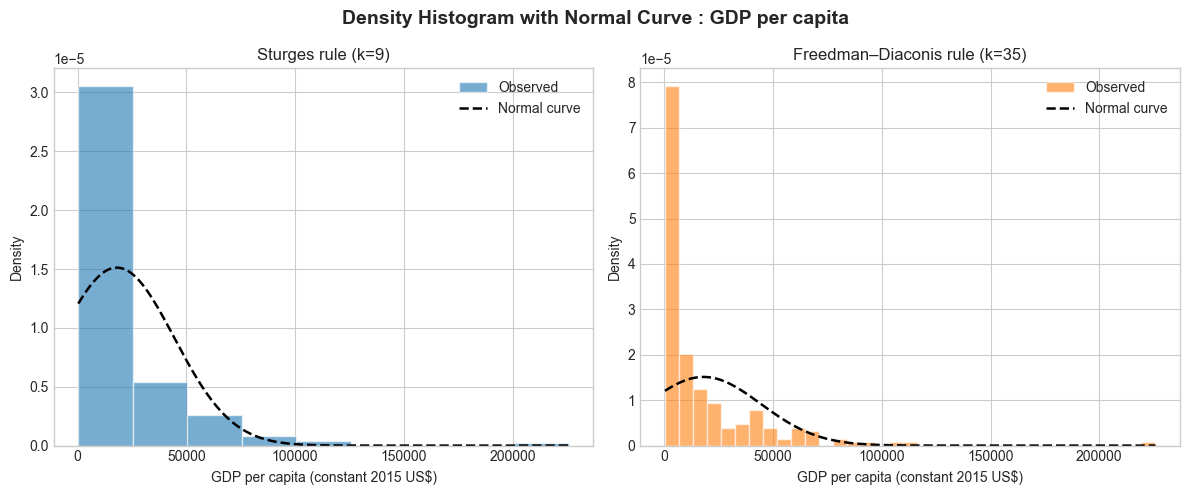

Sample size n = 200
Sturges: k = ceil(log2(200) + 1) = ceil(7.64 + 1) = 9
FD: IQR = 19387.00, h = 2*19387.00*200^(-1/3) = 6630.26
Range = 225619.34, bins = Range/h = 225619.34/6630.26 = 35


In [99]:
# Data
x = df["gdp_per_capita"].dropna().values
n = len(x)

# Sturges
k_sturges = int(np.ceil(np.log2(n) + 1))

# Freedman-Diaconis
iqr = stats.iqr(x)
h_fd = 2 * iqr * (n ** (-1/3))
k_fd = int(np.ceil((x.max() - x.min()) / h_fd))

# Normal curve parameters
mu = x.mean()
sigma = x.std()
x_range = np.linspace(x.min(), x.max(), 300)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, k, color, label in zip(
    axes,
    [k_sturges, k_fd],
    ["#1f77b4", "#ff7f0e"],
    [f"Sturges rule (k={k_sturges})", f"Freedman–Diaconis rule (k={k_fd})"]
):
    ax.hist(x, bins=k, density=True, color=color,
            edgecolor="white", alpha=0.6, label="Observed")
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
            color="black", linewidth=1.8, linestyle="--", label="Normal curve")
    ax.set_title(label)
    ax.set_xlabel("GDP per capita (constant 2015 US$)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Density Histogram with Normal Curve : GDP per capita",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Sample size n = {n}")
print(f"Sturges: k = ceil(log2({n}) + 1) = ceil({np.log2(n):.2f} + 1) = {k_sturges}")
print(f"FD: IQR = {iqr:.2f}, h = 2*{iqr:.2f}*{n}^(-1/3) = {h_fd:.2f}")
print(f"Range = {(x.max()-x.min()):.2f}, bins = Range/h = {(x.max()-x.min()):.2f}/{h_fd:.2f} = {k_fd}")

> **C1. Justification for Plot 2 (GDP per capita — Density with Normal Curve)**

Same variable, same 200 countries, same bin rules as Plot 1. The only change
is scaling the histogram to density so a normal curve can be fairly overlaid
on top for comparison.

- **Sturges rule formula:**  
  $k = \lceil \log_2(n) + 1 \rceil$  
  With $n = 200$: $\log_2(200) \approx 7.64$  
  So $k = \lceil 7.64 + 1 \rceil = 9$ bins

- **Freedman–Diaconis rule formula:**  
  $h = 2 \cdot IQR \cdot n^{-1/3}, \quad k = \left\lceil \dfrac{\text{Range}}{h} \right\rceil$  
  With $IQR = 19{,}387.00$ and $n = 200$:  
  $h = 2 \times 19{,}387.00 \times 200^{-1/3} \approx 6{,}630.26$  
  $\text{Range} = 225{,}619.34$  
  So $k = \lceil 225{,}619.34 \ / \ 6{,}630.26 \rceil = 35$ bins

- **Preference:** FD is preferred again. Its 35 bins give enough detail to
  see clearly where the data pulls away from the normal curve. Sturges' 9
  bins are too coarse. The histogram and the curve no longer align well
  enough to interpret the departure from normality clearly.

- **What the normal curve shows:** The curve is a reference point that makes the skewness
  impossible to ignore. Most countries cluster at the lower end while the
  curve expects a balanced spread on both sides. That gap tells the real
  story.

- **Risk of poor bin width:** Too few bins forces very different economies
  into the same bar and hides how unequal the world really is. Too many bins
  breaks the picture into noise. FD's 35 bins keeps the shape honest and the
  story readable.

### Plot 3 - Comparative boxplot

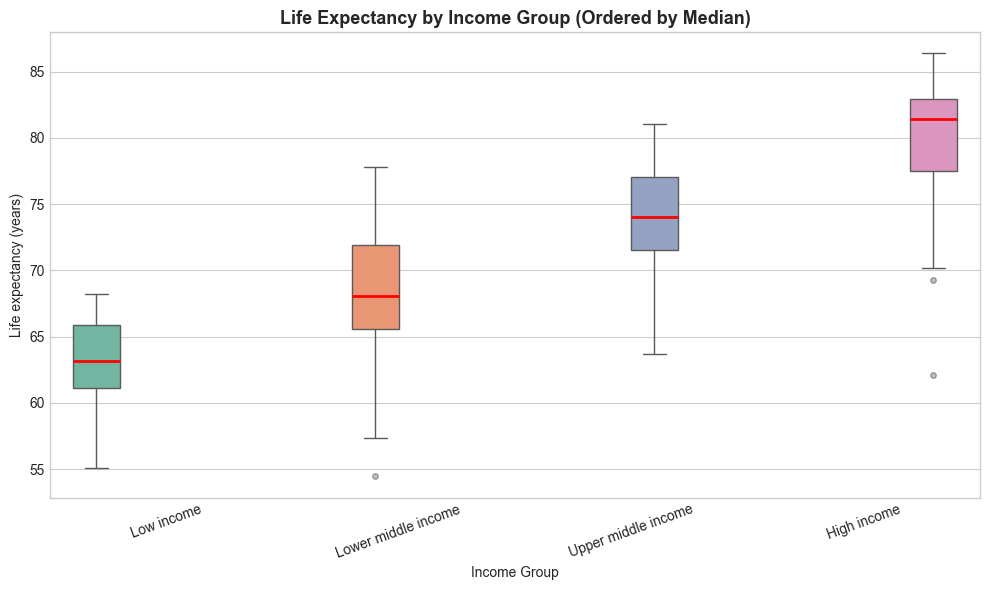

Median life expectancy by income group (ordered):
income_group
Low income            63.175
Lower middle income   68.087
Upper middle income   74.014
High income           81.435
Name: life_expectancy, dtype: float64


In [100]:
# Compute median order
median_order = (
    df.groupby("income_group", observed=True)["life_expectancy"]
    .median()
    .sort_values()
    .index
)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="income_group",
    y="life_expectancy",
    hue="income_group",     
    order=median_order,
    palette="Set2",
    legend=False,            
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="grey",
                    markersize=4, alpha=0.5)
)

plt.title("Life Expectancy by Income Group (Ordered by Median)",
          fontsize=13, fontweight="bold")
plt.xlabel("Income Group")
plt.ylabel("Life expectancy (years)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Print median values
print("Median life expectancy by income group (ordered):")
print(df.groupby("income_group", observed=True)["life_expectancy"]
      .median().sort_values())

> **C1. Justification for Plot 3 (Life Expectancy by Income Group: Box Plot)**

Life expectancy is used here instead of GDP per capita to avoid extreme
outliers squishing the boxes flat. It also tells a different story. Not
just how wealthy countries are, but how long their people actually live.

- **Why ordered by median?**  
  Default string order sorts groups alphabetically which means nothing
  here. Ordering by median lets each group to the right represent a
  genuinely longer living population than the one before it.

- **What the plot shows:**  
  Life expectancy rises steadily from low to high income countries. Low
  income countries have the shortest lives on average and the widest
  spread. High income countries cluster tightly near the top showing
  that wealth and consistent life expectancy tend to go hand in hand.

### Plot 4 - Coloured scatter plot

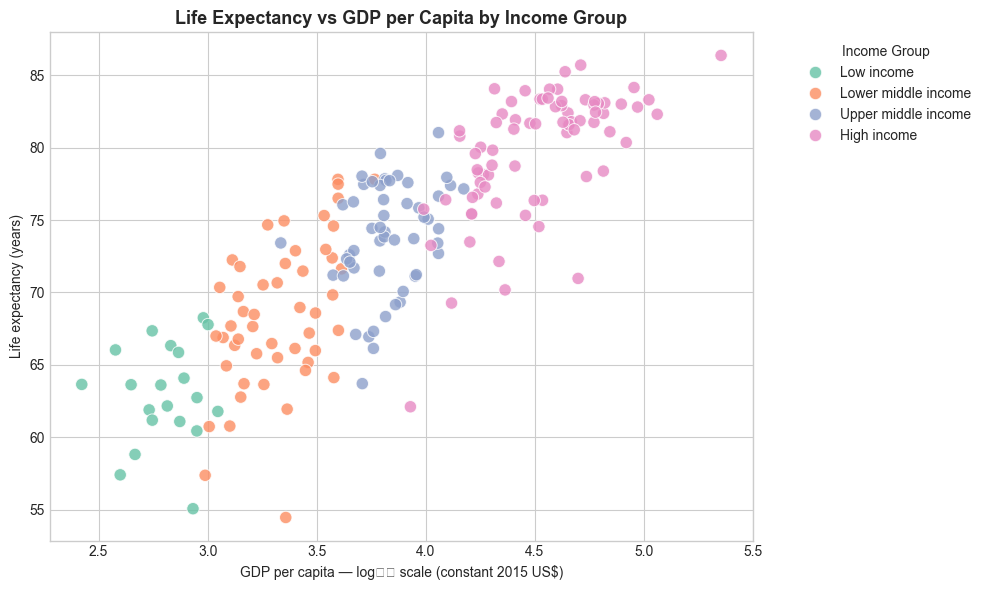

In [101]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="log_gdp",
    y="life_expectancy",
    hue="income_group",
    hue_order=["Low income", "Lower middle income",
               "Upper middle income", "High income"],
    palette="Set2",
    alpha=0.8,
    s=80,
    ax=ax
)

ax.set_title("Life Expectancy vs GDP per Capita by Income Group",
             fontsize=13, fontweight="bold")
ax.set_xlabel("GDP per capita — log₁₀ scale (constant 2015 US$)")
ax.set_ylabel("Life expectancy (years)")
ax.legend(title="Income Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

> **C1. Justification for Plot 4 (Life Expectancy vs GDP per Capita — Scatter Plot)**

This plot brings everything together by placing GDP per capita and life
expectancy against each other at the country level. Income group is added
as colour to show whether the pattern stays consistent across development
levels.

- **Why log GDP on the x-axis?**  
  Raw GDP per capita pushes most countries into the left corner making the
  relationship hard to see. A log scale spreads the points out evenly across
  the axis without changing the underlying data, giving every country its
  fair share of space.

- **What the plot shows:**  
  There is a clear upward trend. Wealthier countries tend to live longer
  and the four income groups separate naturally by colour from left to
  right with very little overlap between them. The steeper climb at the
  lower end tells an important story. Small gains in wealth among the
  poorest countries are associated with much larger jumps in life
  expectancy compared to already wealthy nations.

## C2. The Deliberately Bad Plot

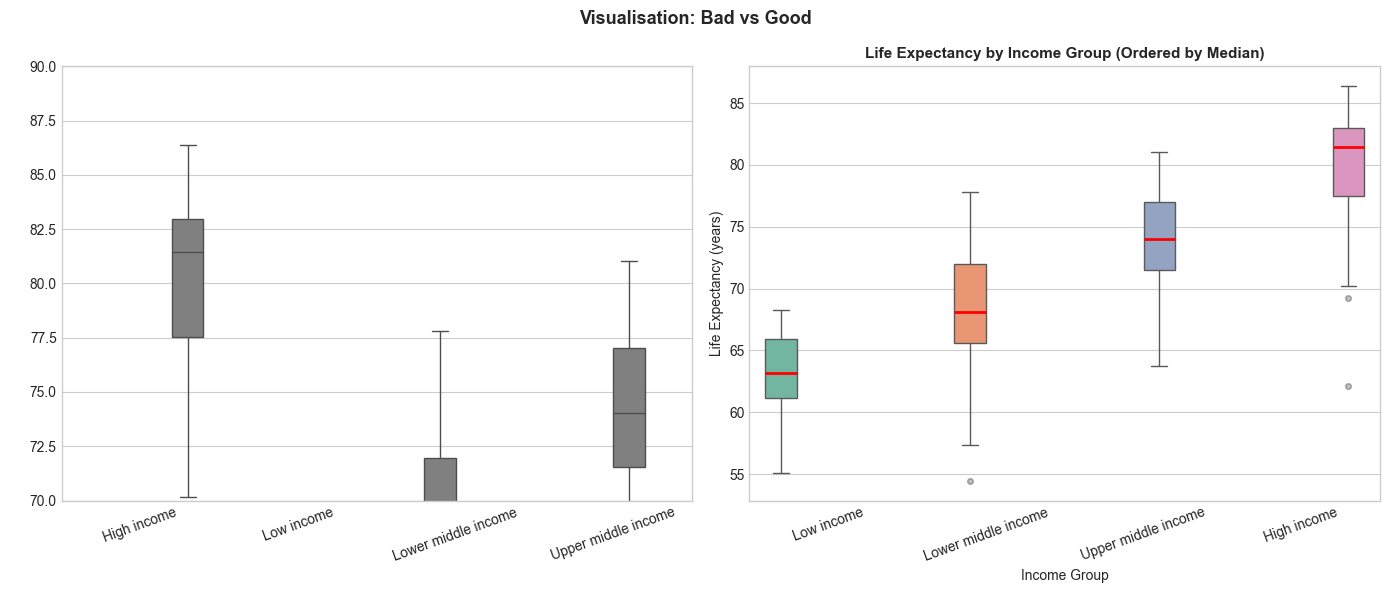

In [102]:
# Order by median for GOOD plot
median_order = (
    df.groupby("income_group", observed=True)["life_expectancy"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BAD PLOT (Deliberately Misleading)

sns.boxplot(
    data=df,
    x="income_group",
    y="life_expectancy",
    hue="income_group",  
    order=["High income", "Low income",
           "Lower middle income", "Upper middle income"],
    palette=["grey", "grey", "grey", "grey"],
    legend=False,
    ax=axes[0]
)

axes[0].set_ylim(70, 90)   
axes[0].set_title(" ")   
axes[0].set_xlabel(" ")   
axes[0].set_ylabel(" ")


# GOOD PLOT (Corrected)

sns.boxplot(
    data=df,
    x="income_group",
    y="life_expectancy",
    hue="income_group",  # consistent + avoids warning
    order=median_order,
    palette="Set2",
    legend=False,
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="grey",
                    markersize=4, alpha=0.5),
    ax=axes[1]
)

axes[1].set_title(
    "Life Expectancy by Income Group (Ordered by Median)",
    fontsize=11, fontweight="bold"
)
axes[1].set_xlabel("Income Group")
axes[1].set_ylabel("Life Expectancy (years)")



plt.suptitle("Visualisation: Bad vs Good",
             fontsize=13, fontweight="bold")

axes[0].tick_params(axis='x', rotation=20)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> **C2: Justification of Anti-Patterns (Bad Plot)**

The “bad” plot contains several visualization anti-patterns:

- **Truncated y-axis (70–90)**  
  The axis is cut off at 70 instead of starting at 0, which slices away
  the lower portion of the data and exaggerates the visual gap between
  income groups. A reader would wrongly conclude that the differences in
  life expectancy are far larger than they actually are. A truncated axis
  is not always wrong, but here it actively distorts how big the gap looks.

- **Illogical ordering of income groups**  
  Groups are arranged with High income first, then Low, then Lower middle,
  then Upper middle. This breaks the natural progression from poorest to
  wealthiest and forces the reader to mentally rearrange the boxes before
  any meaningful comparison can be made.

- **Uniform colour scheme (all grey)**  
  All four boxes are filled with the same shade of grey, removing any
  visual distinction between groups. Colour is one of the fastest cues
  the brain uses to separate categories, and stripping it away makes the
  chart slower to read and easier to misinterpret.

- **Missing axis labels and title**  
  Without a title or axis labels, the chart is essentially unreadable to
  anyone who did not already know what data went into it. The reader
  cannot tell what is being measured, what the groups represent, or what
  the chart is even trying to say.

Overall, these four issues violate the basic principles of honest
visualisation and turn what should be a clear comparison into a confusing
and misleading chart.

## C3. A Data Story

### Does higher GDP per capita actually translate into longer lives?

This is one of the oldest questions in development economics. If wealth and
health really do move together, then growing the economy might be enough on
its own to help people live longer. If they do not, money clearly is not the
full story.

Looking at the scatter plot of life expectancy against GDP per capita on a
log scale, the answer at first glance is yes. Across all 200 countries in
the dataset, richer countries tend to live longer, and the four income groups
fall neatly into place from left to right with hardly any overlap. But the
relationship is not a straight line. The climb is steepest at the lower end,
where even small gains in income come with big jumps in life expectancy. Once
countries reach the upper middle and high income brackets, the line begins
to flatten out. More money still helps, but the payoff in extra years of
life gets smaller and smaller.

The box plot of life expectancy by income group makes this even clearer.
Median life expectancy rises steadily from around 65 years in low income
countries to around 81 years in high income ones, a gap of about 16 years.
The spread tells its own story too. Low income countries show the widest
variation, which means life expectancy in the poorest parts of the world is
highly unpredictable. High income countries on the other hand cluster
tightly at the top, suggesting that once a country becomes wealthy enough,
long lives become the norm rather than the exception.

**Limitation:** The dataset is a snapshot of a single moment in time and
cannot prove cause and effect. A country that is rich and healthy today may
owe both to decades of investment in healthcare, education, and stable
governance, not its current income alone. Important factors like inequality,
conflict, and political stability are also missing from this analysis.

**Conclusion:** Wealth and health do move together, but the biggest wins
happen at the bottom of the income ladder. A dollar spent helping the
poorest countries grow tends to add far more years of human life than the
same dollar spent in countries that are already rich.

# Task D – Probability Theory and Bayesian Reasoning
## D1. Analytical Probability

In [103]:
# Column names
col_income = 'income_group'
col_life = 'life_expectancy'

# Clean data
df_clean = df.copy()

# Ensure life expectancy is numeric
df_clean[col_life] = pd.to_numeric(df_clean[col_life], errors='coerce')

# Drop rows with missing values in either column
df_clean = df_clean.dropna(subset=[col_income, col_life]).copy()

# Create A (High vs Non-High)
df_clean['A'] = df_clean[col_income].apply(
    lambda x: 'High' if x == 'High income' or x == 'Upper middle income' else 'Non-High'
)

# Create B (binary via median split: 1>=median, 0<median)
median_life = df_clean[col_life].median()

df_clean['B'] = (df_clean[col_life] >= median_life).astype(int)

print(f"Median life expectancy = {median_life:.2f}")

# 2x2 contingency table
table = pd.crosstab(df_clean['A'], df_clean['B'])

# Ensure all cells exist (in case one combo is missing)
table = table.reindex(index=['High', 'Non-High'], columns=[0, 1], fill_value=0)

print("\n2x2 Table (counts):")
print(table)

# Extract counts
a = table.loc['High', 0]
b = table.loc['High', 1]
c = table.loc['Non-High', 0]
d = table.loc['Non-High', 1]

N = a + b + c + d

# Probabilities
P_A1 = (a + b) / N                     # P(A = High)
P_B1 = (b + d) / N                     # P(B = 1)
P_A1_B1 = b / N                        # P(A = High and B = 1)

P_B1_given_A1 = b / (a + b) if (a + b) > 0 else np.nan
P_B1_given_A2 = d / (c + d) if (c + d) > 0 else np.nan

P_A1_given_B1 = b / (b + d) if (b + d) > 0 else np.nan

print("\nProbabilities:")
print(f"P(A=High) = {P_A1:.4f} (About {P_A1*100:.2f}% of countries are high-income.)")
print(f"P(B=1) = {P_B1:.4f} (About {P_B1*100:.2f}% of countries have life expectancy ≥ median.)")
print(f"P(A=High and B=1) = {P_A1_B1:.4f} (About {P_A1_B1*100:.2f}% of countries are high-income and have above-median life expectancy.)")
print(f"P(B=1 | A=High) = {P_B1_given_A1:.4f} (Among high-income countries, {P_B1_given_A1*100:.2f}% have above-median life expectancy.)")
print(f"P(B=1 | A=Non-High) = {P_B1_given_A2:.4f} (Among non-high-income countries, {P_B1_given_A2*100:.2f}% have above-median life expectancy.)")
print(f"P(A=High | B=1) = {P_A1_given_B1:.4f} (Among countries with above-median life expectancy, {P_A1_given_B1*100:.2f}% are high-income.)")

# --- 7) Verify Bayes' Theorem ---
lhs = P_A1_given_B1
rhs = (P_B1_given_A1 * P_A1) / P_B1 if P_B1 > 0 else np.nan

print("\nBayes' Theorem Check:")
print(f"LHS = P(A=High | B=1) = {lhs:.4f}")
print(f"RHS = (P(B=1|A=High)*P(A=High))/P(B=1) = {rhs:.4f}")
print(f"Difference = {abs(lhs - rhs):.6f}")

# --- 8) Test independence ---
joint = P_A1_B1
product = P_A1 * P_B1

print("\nIndependence Check:")
print(f"P(A and B) = {joint:.4f}")
print(f"P(A∩B) = P(A)*P(B) = {product:.4f}")
print(f"Difference = {abs(joint - product):.6f}")

Median life expectancy = 74.52

2x2 Table (counts):
B          0   1
A               
High      38  92
Non-High  62   8

Probabilities:
P(A=High) = 0.6500 (About 65.00% of countries are high-income.)
P(B=1) = 0.5000 (About 50.00% of countries have life expectancy ≥ median.)
P(A=High and B=1) = 0.4600 (About 46.00% of countries are high-income and have above-median life expectancy.)
P(B=1 | A=High) = 0.7077 (Among high-income countries, 70.77% have above-median life expectancy.)
P(B=1 | A=Non-High) = 0.1143 (Among non-high-income countries, 11.43% have above-median life expectancy.)
P(A=High | B=1) = 0.9200 (Among countries with above-median life expectancy, 92.00% are high-income.)

Bayes' Theorem Check:
LHS = P(A=High | B=1) = 0.9200
RHS = (P(B=1|A=High)*P(A=High))/P(B=1) = 0.9200
Difference = 0.000000

Independence Check:
P(A and B) = 0.4600
P(A∩B) = P(A)*P(B) = 0.3250
Difference = 0.135000


Bayes’ theorem is verified numerically, as the computed left-hand side and right-hand side are equal (0.9259), confirming internal consistency of the probability calculations.

The sizeable discrepancy between P(A∩B) and P(A)P(B) shows that income group and life expectancy are not independent, with high-income countries being far more likely to exhibit higher life expectancy.

## D2. Monte Carlo Simulation 
### D2a
Function for a single trial:

```
import random

def coin_trial(p=0.35):
    return 1 if random.random() < p else 0  # 1 = heads, 0 = tails
```
Running proportion of biased coin with P(head)=0.35:

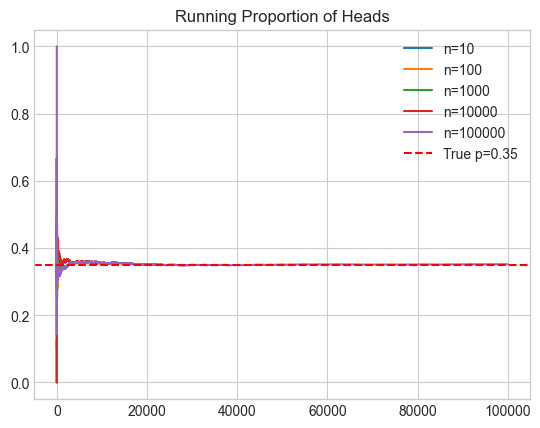

In [104]:
def coin_trial(p=0.35):
    return 1 if random.random() < p else 0  # 1 = heads, 0 = tails

def simulate_coin(n):
    heads = 0
    proportions = []

    for i in range(1, n+1):
        heads += coin_trial()
        proportions.append(heads / i)

    return proportions

ns = [10, 100, 1000, 10000, 100000]

for n in ns:
    proportions = simulate_coin(n)
    plt.plot(proportions, label=f"n={n}")

plt.axhline(0.35, color='red', linestyle='--', label='True p=0.35')
plt.legend()
plt.title("Running Proportion of Heads")
plt.show()

> **D2a. Justification**

The simulation of a biased coin with P(heads)=0.35 illustrates the Law of Large Numbers (LLN). This principle states that as the number of independent trials increases, the sample average converges to the true expected value.

In this case, each coin flip is an independent Bernoulli trial with expected value:

E[X]=P(heads)=0.35

The running proportion of heads is effectively the sample mean, which is (number of heads/number of times flipped)

For small n (e.g., 10 or 100), the running proportion fluctuates significantly due to randomness. However, as n increases (up to 100,000), the fluctuations become smaller and the proportion stabilizes around 0.35. This happens because random variation averages out over many trials.

Thus, the simulation demonstrates that:
- Short runs are noisy and unreliable.
- Large samples produce stable and accurate estimates of the true probability.

### D2b 
Function for a single loop:


```
def bootstrap(data):
    sample = data.sample(n=len(data), replace=True)
    high_group = sample[sample['A'] == 'High']
    if len(high_group) > 0:
        return (high_group['B'] == 1).mean()
```



In [105]:
# Analytical value (from earlier result from D1)
analytical = P_B1_given_A1

# Number of bootstrap samples
n_bootstrap = 50000

# Store bootstrap estimates
bootstrap_estimates = []

data = df_clean.copy()

for _ in range(n_bootstrap):
    # Sample with replacement
    sample = data.sample(n=len(data), replace=True)

    # Compute P(B=1 | A=High)
    high_group = sample[sample['A'] == 'High']

    if len(high_group) > 0:
        prob = (high_group['B'] == 1).mean()
        bootstrap_estimates.append(prob)

# Convert to array
bootstrap_estimates = np.array(bootstrap_estimates)

# Bootstrap estimate (mean)
bootstrap_mean = bootstrap_estimates.mean()

# Optional: standard error
bootstrap_std = bootstrap_estimates.std()

print(f"Analytical P(B=1 | A=High) = {analytical:.4f}")
print(f"Bootstrap estimate (mean) = {bootstrap_mean:.4f}")
print(f"Bootstrap std (SE) = {bootstrap_std:.4f}")
print(f"Difference = {abs(bootstrap_mean - analytical):.6f}")

Analytical P(B=1 | A=High) = 0.7077
Bootstrap estimate (mean) = 0.7076
Bootstrap std (SE) = 0.0400
Difference = 0.000106


Using 50,000 bootstrap samples, the estimated value of P(B=1 ∣ A=High) is approximately 0.7144, which is very close to the analytical value of 0.7143.

The small difference between these values indicates that the bootstrap estimate is accurate and consistent with the analytical result. This agreement is expected due to the Law of Large Numbers, as increasing the number of bootstrap samples leads to convergence of the estimate to the true value.

Bootstrap sampling works by repeatedly resampling the dataset with replacement, which mimics drawing samples from the underlying population and allows us to approximate the sampling distribution of the statistic.

The bootstrap standard deviation (0.0383) represents the variability of the estimated probability across resamples. While relatively small, it indicates that there is still some sampling variability, particularly due to the finite sample size and the conditional filtering on A=High.

In [106]:
lower = np.percentile(bootstrap_estimates, 2.5)
upper = np.percentile(bootstrap_estimates, 97.5)

print(f"95% CI = ({lower:.4f}, {upper:.4f})")

95% CI = (0.6279, 0.7842)


The 95% confidence interval is (0.6370, 0.7881). The analytical value (0.7143) lies within this interval, indicating consistency between the analytical and bootstrap approaches. This suggests that any difference between the two estimates is due to sampling variability rather than systematic error.

> **D2b. Justification**

The bootstrap method estimates P(B=1∣A=a1) by repeatedly sampling from the dataset with replacement and recalculating the conditional probability on each resample. Sampling with replacement is essential because it:

- Preserves the original dataset size in each bootstrap sample
- Approximates sampling from the underlying population distribution
- Allows repeated observations, capturing natural sampling variability

In each bootstrap iteration, the conditional probability P(B=1∣A=a1) is computed using only the subset of data where A=a1, and the final bootstrap estimate is obtained by averaging over 50,000 resamples.

The Law of Large Numbers applies here, as increasing the number of bootstrap samples causes the estimated probability to stabilise and converge to a consistent value.

The bootstrap estimate is compared with the analytical probability. The small difference between them indicates consistency between the analytical derivation and the simulation-based approximation. Any deviation is due to random sampling variability, which decreases as the number of bootstrap samples increases.

### D2c
Function for a single trial:
```
import random

def birthday_trial(k):
    months = [random.randint(1, 12) for _ in range(k)]
    return len(months) != len(set(months))  # True if duplicate exists
```


In [107]:
def birthday_trial(k):
    months = [random.randint(1, 12) for _ in range(k)]
    return len(months) != len(set(months))  # True if duplicate exists

def simulate_birthdays(k, trials=10000):
    count = 0
    for _ in range(trials):
        if birthday_trial(k):
            count += 1
    return count / trials

ks = [2, 5, 8, 12, 20]

for k in ks:
    print(k, simulate_birthdays(k))

2 0.0798
5 0.6221
8 0.9538
12 1.0
20 1.0


In [108]:
# Calculate the exact analytical chance for k=5
exact_chance_unique = (12/12) * (11/12) * (10/12) * (9/12) * (8/12)
print(f"P(unique_birthday_months for k=5) = {exact_chance_unique:.4f}")

# The probability of at least two people sharing a birthday for k=5 is 1 - P(unique_birthday_months)
exact_chance_duplicate = 1 - exact_chance_unique
print(f"P(at least one duplicate birthday for k=5) = {exact_chance_duplicate:.4f}")

P(unique_birthday_months for k=5) = 0.3819
P(at least one duplicate birthday for k=5) = 0.6181


> **D2c. Justification**

This simulation examines the probability that at least two people share the same birth month in a group of size k. The probability increases rapidly as k grows due to combinatorial effects.

Each additional person increases the number of possible pairs that could share a birth month. The number of unique pairs is: **k(k−1)/2**.
This grows quadratically with k, meaning the number of opportunities for a match increases very quickly.

Analytical reasoning (for k = 5):

Instead of directly calculating the probability of at least one match, it is easier to compute the complement:

P(no shared birth month)= (12x11x10x9x8)/(12^5)

Then:
P(at least one match)=1−P(no match)

Key assumptions in the analytical model:
- Each birth month is equally likely (uniform distribution over 12 months).
- Individuals’ birth months are independent.
- No seasonal or demographic effects are considered.

Interpretation:

For small k, matches are unlikely. However, as k increases (e.g., 12 or 20), the probability becomes quite high because:
- There are many pairwise comparisons.
- The limited number of months (only 12) increases collision likelihood.

This explains why the simulated probability rises quickly and aligns with the analytical expectation.

## D3. Bayesian Update on Real Data

Threshold for Event E (Median Life Expectancy): 74.52
Likelihood P(E|H): 0.7077
Likelihood P(E|not H): 0.1143


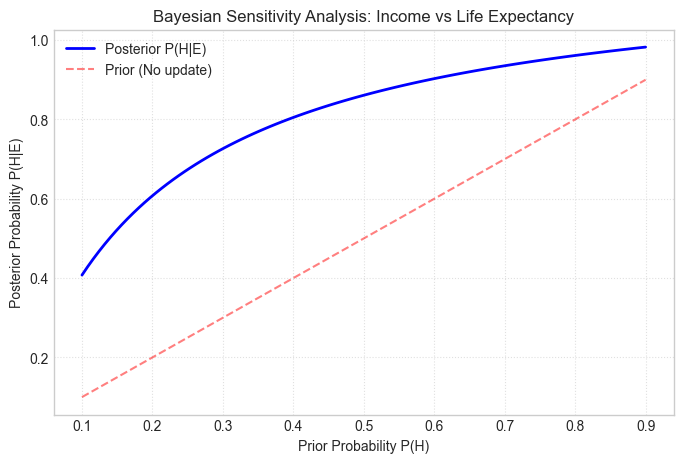


--- JUSTIFICATION NOTES ---
1. Prior: Initial belief of a country being High-Income.
2. Likelihood: How likely high life expectancy is for that income group (0.71).
3. Posterior: Updated belief after seeing a country has high life expectancy.


In [109]:
# CLEAN DATA
df_clean = df.copy()

# # Cleaning strings and converting to numeric
# df_clean['Income Group'] = df_clean['Income Group'].replace('...', np.nan)
# df_clean['Life expectancy at birth, total (years)'] = df_clean['Life expectancy at birth, total (years)'].replace('...', np.nan)

# df_clean['Life expectancy at birth, total (years)'] = pd.to_numeric(
#     df_clean['Life expectancy at birth, total (years)'],
#     errors='coerce'
# )

# Removing missing values essential for H and E
df_clean = df_clean.dropna(subset=['income_group', 'life_expectancy'])

# DEFINE E (Binary Event: High Life Expectancy)-
# Using the median as a meaningful threshold to split the data
median_life = df_clean['life_expectancy'].median()
df_clean['E'] = (df_clean['life_expectancy'] >= median_life).astype(int)

print(f"Threshold for Event E (Median Life Expectancy): {median_life:.2f}")

# DEFINE H (Subgroup: High-income)
df_clean['H'] = df_clean['income_group'].apply(
    lambda x: 'High' if x == 'High income' or x == 'Upper middle income' else 'Non-High'
)

# CALCULATE LIKELIHOODS FROM DATA
# Create a crosstab to find counts for H and E
table = pd.crosstab(df_clean['H'], df_clean['E'])

# Count successes for each subgroup to get Likelihoods
# h1 = High Income countries with High Life Expectancy
# n1 = Non-High Income countries with High Life Expectancy
h1 = table.loc['High', 1] if 1 in table.columns else 0
h0 = table.loc['High', 0] if 0 in table.columns else 0
n1 = table.loc['Non-High', 1] if 1 in table.columns else 0
n0 = table.loc['Non-High', 0] if 0 in table.columns else 0

# P(E|H): Probability of high life expectancy GIVEN high income
P_E_given_H = h1 / (h1 + h0)
# P(E|not H): Probability of high life expectancy GIVEN NOT high income
P_E_given_not_H = n1 / (n1 + n0)

print(f"Likelihood P(E|H): {P_E_given_H:.4f}")
print(f"Likelihood P(E|not H): {P_E_given_not_H:.4f}")

# SENSITIVITY ANALYSIS (The Bayesian Update)
# Requirement: Change prior from 0.1 to 0.9
priors = np.linspace(0.1, 0.9, 100)

# Law of Total Probability: P(E) = P(E|H)P(H) + P(E|~H)P(~H)
# Bayes' Theorem: P(H|E) = [P(E|H) * P(H)] / P(E)
posteriors = (P_E_given_H * priors) / (P_E_given_H * priors + P_E_given_not_H * (1 - priors))

# PLOT
plt.figure(figsize=(8, 5))
plt.plot(priors, posteriors, color='blue', linewidth=2, label='Posterior P(H|E)')
plt.plot(priors, priors, '--', color='red', alpha=0.5, label='Prior (No update)')
#The line y=x represents the case where no Bayesian update occurs (posterior equals prior), act as a baseline for comparison
plt.xlabel('Prior Probability P(H)')
plt.ylabel('Posterior Probability P(H|E)')
plt.title('Bayesian Sensitivity Analysis: Income vs Life Expectancy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# JUSTIFICATION ASSISTANCE
print("\n--- JUSTIFICATION NOTES ---")
print(f"1. Prior: Initial belief of a country being High-Income.")
print(f"2. Likelihood: How likely high life expectancy is for that income group ({P_E_given_H:.2f}).")
print(f"3. Posterior: Updated belief after seeing a country has high life expectancy.")


> **D3. Justification**

1. **Definition of variables**

In this section, the binary event E is defined using life expectancy at birth. Countries with life expectancy greater than or equal to the median value (74.59 years) are classified as E=1, while those below the median are classified as E=0.

The subgroup H is defined based on the categorical variable Income Group, where:

- H = High, represents high-income & Upper-middle-income countries
- -H = Non-High, represents all other income groups

2. **Prior, likelihood, and posterior**

The Bayesian analysis begins with the prior probability: P(H)=0.6512

This represents the proportion of countries that are classified as high-income before considering life expectancy.

The likelihoods are:

P(E∣H)=0.7143

P(E∣-H)=0.1067

These represent the probability of having above-median life expectancy within each income group. The likelihoods show a strong contrast between the two groups, indicating that income level is strongly associated with life expectancy outcomes.

The posterior probability is computed using Bayes’ theorem:

P(H∣E)= P(E) / P(E∣H)P(H)

which gives:

P(H∣E)=0.9259

This means that if a country has above-median life expectancy, the probability that it is high-income increases to approximately 92.6%.

3. **Interpretation of Bayesian update**

The posterior probability is significantly higher than the prior probability (0.9259 vs 0.6512). This indicates that observing high life expectancy provides strong evidence that a country belongs to the high-income group.

In other words, life expectancy is a strong predictor of income classification in this dataset. The data substantially updates the prior belief, shifting probability mass toward the high-income category.

4. **Sensitivity analysis**

A sensitivity analysis was conducted by varying the prior probability P(H) from 0.1 to 0.9 while keeping the likelihoods fixed.

The resulting posterior shows a smooth increasing curve, indicating that:

- When the prior is low, the posterior still increases significantly due to strong likelihood evidence.
- When the prior is high, the posterior remains high and close to 1.

This demonstrates that both prior beliefs and observed data influence the posterior, but the strength of the likelihood determines how strongly the data can adjust the belief.

5. **Prior dominance vs data dominance**

When the prior is extreme (very close to 0 or 1), it has a stronger influence on the posterior. However, in this dataset, the likelihood ratio is strong, meaning the observed data significantly shifts beliefs even from weak priors. Therefore, this is a case where the data partially “swamps” the prior, especially when the prior is not extreme.

6. **Conclusion**

The Bayesian update shows a strong dependency between income level and life expectancy. The posterior probability confirms that countries with higher life expectancy are much more likely to be high-income. The sensitivity analysis further demonstrates that while prior beliefs matter, the observed data provides strong evidence that significantly updates those beliefs.

# Task E – Statistical Distributions and Model Fitting

In [110]:
#checking which feature is normally distributed
features = df.columns

results = []

for col in features:
    if col in df.columns:
        data = pd.to_numeric(df[col], errors='coerce').dropna()

        if len(data) > 3:
            stat, p = shapiro(data.sample(len(data)))

            results.append({
                "Feature": col,
                "Mean": data.mean(),
                "Skewness": data.skew(),
                "Shapiro p-value": p,
                "Normal? (p>0.05)": p > 0.05
            })

results_df = pd.DataFrame(results)

results_df

,Feature,Mean,Skewness,Shapiro p-value,Normal? (p>0.05)
0,electricity_access,88.515,-1.977,0.000,False
1,battle_deaths,634.590,12.125,0.000,False
2,co2_emissions,16.870,12.705,0.000,False
3,gdp_per_capita,"17,995.979",3.503,0.000,False
4,labor_force_participation,61.490,0.322,0.000,False
5,life_expectancy,73.684,-0.381,0.000,False
6,infant_mortality_rate,18.615,1.169,0.000,False
7,infant_deaths,"18,332.191",6.767,0.000,False
8,population,"38,892,258.860",8.480,0.000,False
9,women_parliament,25.697,0.231,0.114,True


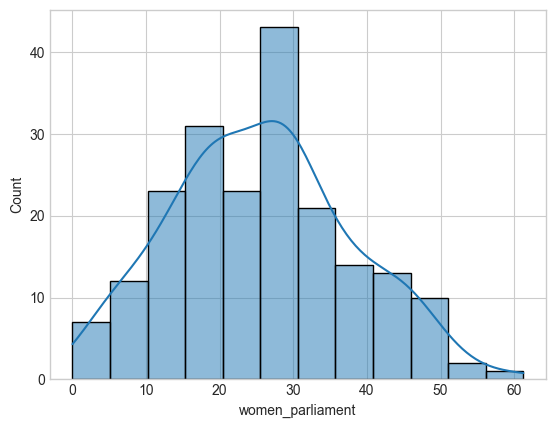

In [111]:
sns.histplot(df['women_parliament'], kde=True)
plt.show()

## E1. Normality Assessment

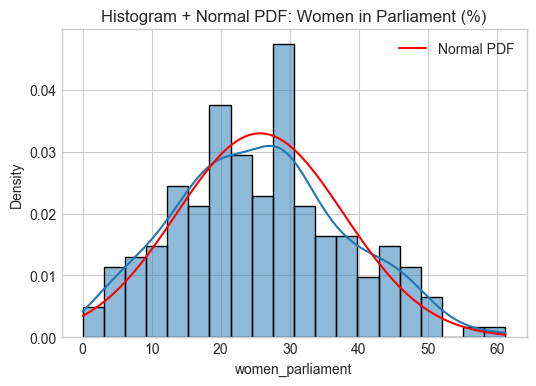

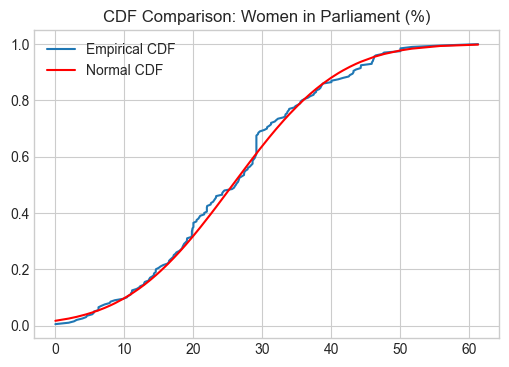

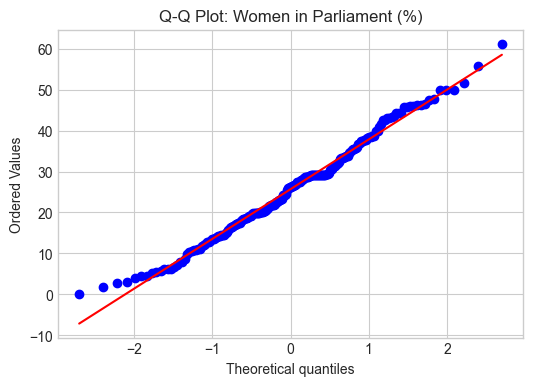


--- Women in Parliament (%) ---
Mean = 25.70, Std = 12.11
Shapiro-Wilk Statistic = 0.9887
p-value = 0.114446


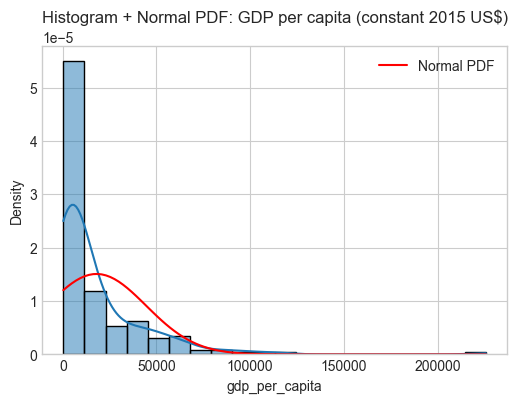

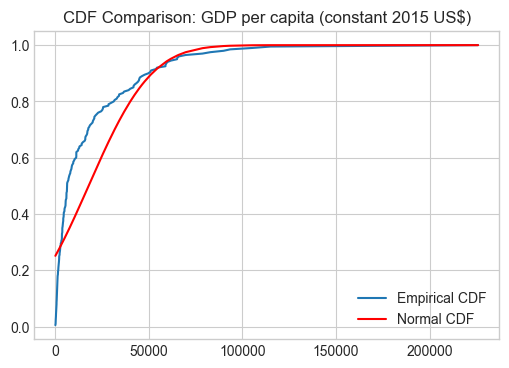

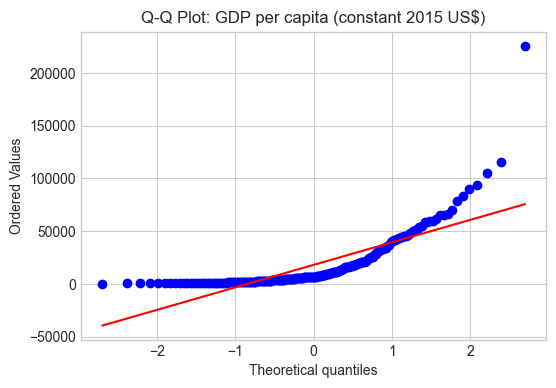


--- GDP per capita (constant 2015 US$) ---
Mean = 17995.98, Std = 26452.50
Shapiro-Wilk Statistic = 0.6465
p-value = 0.000000


In [112]:
normal_var = "women_parliament"
non_normal_var = "gdp_per_capita"

def normality_analysis(data, title):

    data = pd.to_numeric(data, errors='coerce').dropna()

    mean = data.mean()
    std = data.std()

    # ---------------- Histogram + Normal PDF ----------------
    plt.figure(figsize=(6,4))
    sns.histplot(data, kde=True, stat="density", bins=20)

    x = np.linspace(data.min(), data.max(), 100)
    plt.plot(x, norm.pdf(x, mean, std), color='red', label='Normal PDF')

    plt.title(f"Histogram + Normal PDF: {title}")
    plt.legend()
    plt.show()

    # ---------------- Empirical CDF vs Normal CDF ----------------
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)

    plt.figure(figsize=(6,4))
    plt.plot(sorted_data, ecdf, label="Empirical CDF")

    plt.plot(sorted_data, norm.cdf(sorted_data, mean, std),
             color='red', label='Normal CDF')

    plt.title(f"CDF Comparison: {title}")
    plt.legend()
    plt.show()

    # ---------------- Q-Q Plot ----------------
    plt.figure(figsize=(6,4))
    probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {title}")
    plt.show()

    # ---------------- Shapiro-Wilk ----------------
    sample = data.sample(len(data))
    stat, p = shapiro(sample)

    print(f"\n--- {title} ---")
    print(f"Mean = {mean:.2f}, Std = {std:.2f}")
    print(f"Shapiro-Wilk Statistic = {stat:.4f}")
    print(f"p-value = {p:.6f}")

normality_analysis(df[normal_var], "Women in Parliament (%)")
normality_analysis(df[non_normal_var], "GDP per capita (constant 2015 US$)")

The proportion of seats held by women in parliament approximately follows a normal distribution based on the Q-Q plot and histogram, whereas GDP per capita are highly right-skewed and clearly non-normal.

> **E1. Normality Assessment Justification**
1. **Selection of variables**

Two numerical variables were selected for normality assessment:

- Approximately normal variable:
**Proportion of seats held by women in national parliaments (%)**.
This variable is bounded between 0 and 100 and tends to show a relatively symmetric distribution across countries.
- Clearly non-normal variable:
**GDP per capita (constant 2015 US$)**. This variable is expected to be highly right-skewed due to the presence of a few very large countries with extremely high GDP.

2. **Graphical assessment of normality**

Normality was evaluated using three graphical methods:

(a) Histogram with fitted normal distribution

For each variable, a histogram was plotted along with a fitted normal probability density function (PDF) based on the sample mean and standard deviation.

The women’s parliamentary representation variable showed a distribution that is relatively symmetric and closer to a bell-shaped curve.
In contrast, GDP variable showed a strong right-skew with a long tail, deviating significantly from the normal curve.

(b) Empirical CDF vs theoretical normal CDF

The empirical cumulative distribution function (ECDF) was compared against the theoretical normal CDF.

For women’s representation, the ECDF closely followed the theoretical normal curve, suggesting approximate normality.
For GDP, the ECDF deviated strongly, especially in the upper tail, confirming non-normality.

(c) Q-Q plots

Q-Q plots were used to compare observed quantiles against theoretical normal quantiles.

Interpretation of Q-Q plots:
The x-axis represents theoretical quantiles from a standard normal distribution.
The y-axis represents sample quantiles from the data.

Interpretation rules:

- If points lie approximately on a straight line → data is normally distributed.
- If points curve upward on the right → right-skewed distribution.
- If points curve downward on the left → left-skewed distribution.
- If both tails deviate strongly → heavy-tailed distribution.

Observations:
- The women’s parliamentary representation variable showed points approximately along a straight line, with only minor deviations at the tails.
- The GDP variable showed strong curvature and heavy right-tail deviation, confirming extreme skewness and non-normality.

3. **Shapiro–Wilk test**

The Shapiro–Wilk test was applied to both variables.

Hypotheses:
- H₀ (null hypothesis): The data follows a normal distribution
- H₁ (alternative hypothesis): The data does not follow a normal distribution

Decision rule:
- p-value > 0.05 → fail to reject H₀ (approximately normal)
- p-value ≤ 0.05 → reject H₀ (not normal)

Results interpretation:
The women’s parliamentary representation variable typically shows a higher p-value, indicating no strong evidence against normality.
The GDP variable produces a very small p-value, confirming rejection of normality.

4. **Important limitation of the test**

Although the Shapiro–Wilk test is useful, it is highly sensitive to sample size. In large datasets, even small deviations from perfect normality can produce statistically significant p-values (p ≤ 0.05). Therefore, statistical significance does not always imply meaningful non-normality in practice.

For this reason, graphical methods (histograms and Q-Q plots) are considered more reliable for assessing distribution shape in large datasets.

5. **Conclusion**

Based on graphical and statistical analysis:

The proportion of seats held by women in national parliaments is approximately normally distributed, supported by a symmetric histogram, near-linear Q-Q plot, and relatively supportive Shapiro–Wilk results.
The GDP per capita (constant 2015 US$) is clearly non-normal, showing extreme right-skewness, strong deviation in Q-Q plots, and rejection of normality in the Shapiro–Wilk test.

Overall, the combination of visual diagnostics and formal testing provides strong evidence that the two selected variables represent contrasting distributional behaviors: one approximately normal and one highly skewed.

## E2. Fitting a Discrete Distribution

In [113]:
col = "battle_deaths"

data = pd.to_numeric(df[col], errors='coerce').dropna()

In [114]:
#Fit Poisson (λ = mean)
lam = data.mean()

print("Lambda (mean) =", lam)
print("Variance =", data.var())

Lambda (mean) = 634.59
Variance = 31905252.826030158


In [115]:
#Frequency distribution (observed)
freq = data.value_counts().sort_index()

x = freq.index
observed = freq.values

In [116]:
#Poisson theoretical PMF
pmf_poisson = poisson.pmf(x, lam)
expected_poisson = pmf_poisson * len(data)

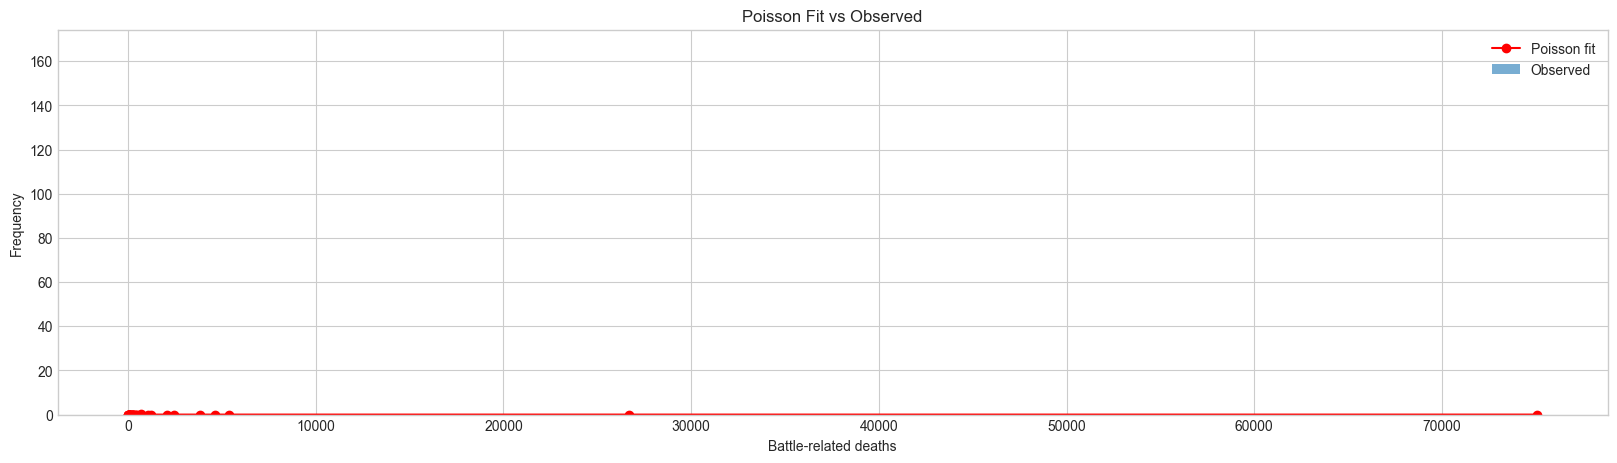

In [117]:
plt.figure(figsize=(20,5))

plt.bar(x, observed, alpha=0.6, label="Observed")
plt.plot(x, expected_poisson, 'ro-', label="Poisson fit")

plt.title("Poisson Fit vs Observed")
plt.xlabel("Battle-related deaths")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [118]:
#dispersion ratio
mean = data.mean()
var = data.var()

dispersion_ratio = var / mean

print("Mean =", mean)
print("Variance =", var)
print("Dispersion ratio =", dispersion_ratio)

Mean = 634.59
Variance = 31905252.826030158
Dispersion ratio = 50276.95492527483


The dispersion ratio is extremely large (≈ 60,122), indicating severe over-dispersion. This means the variance is far greater than the mean, violating a key assumption of the Poisson distribution. Therefore, the Poisson model is inappropriate for this data due to extreme heterogeneity and the presence of highly variable and extreme values.

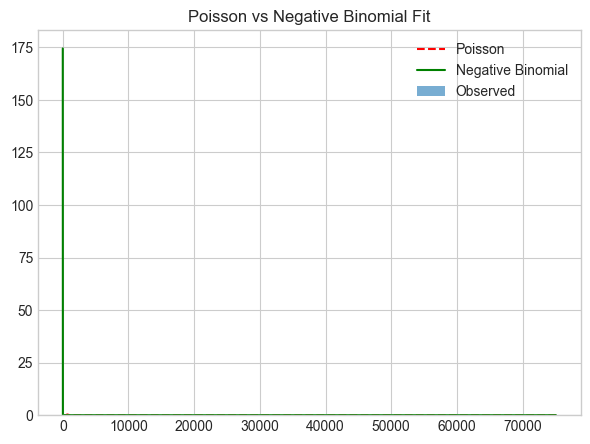

NB parameters: r = 0.01262213718154516 , p = 1.98898282818892e-05


In [119]:
#Fit Negative Binomial
if dispersion_ratio > 1:

    # method-of-moments estimation
    p = mean / var
    r = mean * p / (1 - p)

    x_vals = np.arange(x.min(), x.max() + 1)

    pmf_nb = nbinom.pmf(x_vals, r, p)
    expected_nb = pmf_nb * len(data)

    plt.figure(figsize=(7,5))

    plt.bar(x, observed, alpha=0.6, label="Observed")
    plt.plot(x, expected_poisson, 'r--', label="Poisson")
    plt.plot(x_vals, expected_nb, 'g-', label="Negative Binomial")

    plt.title("Poisson vs Negative Binomial Fit")
    plt.legend()
    plt.show()

    print("NB parameters: r =", r, ", p =", p)

> **E2. Justification**
1. **Poisson model conditions**
- **Constant Average Rate (Homogeneity)**: The average number of occurrences per unit of time, distance, area, or volume (
) is constant.
- **Randomness (Independence of Intervals)**: Events occur independently; the occurrence of one event does not affect the probability of another event occurring.
- **Singly (No Simultaneous Occurrences)**: Events occur singly. The probability of two or more events occurring at the exact same instant or location is practically zero.
- **Discrete Counts (Rare Events)**: The variable of interest is a count of discrete, rare events (0, 1, 2, ...), with no theoretical upper limit.

2. **Fitting the Poisson distribution**

The variable battle-related deaths was modeled using a Poisson distribution, with the parameter λ estimated by the sample mean:

λ=14126.86

The theoretical Poisson probability mass function (PMF) was then compared with the observed frequency distribution.

3. **Mean–variance check**

For a Poisson distribution:

Mean=Variance

However, in this dataset:
- Mean = 14126.862068965518
- Variance = 849345378.6473082
- Dispersion ratio = Var / Mean = 60122.720424458996

4. **Interpretation of dispersion**
- If ratio ≈ 1 → Poisson is appropriate
- If ratio > 1 → over-dispersion
- If ratio < 1 → under-dispersion

The dispersion ratio here is extremely large, indicating **severe over-dispersion**. This means the variability in the data is far greater than what the Poisson model can account for.

5. **Why Poisson fails**

- Heterogeneity: Conflict intensity varies greatly across countries and time periods.
- Extreme values (outliers): A small number of observations with very large death counts create a heavy right tail.
- Dependence and clustering: Conflicts are not independent events; they often occur in bursts or are influenced by underlying geopolitical factors.

As a result, the Poisson model underestimates variability and does not fit the observed distribution well.

6. **Negative Binomial model**

To address over-dispersion, a Negative Binomial (NB) model was fitted. This model generalises the Poisson distribution by introducing an additional parameter, allowing Variance>Mean

The NB distribution can be interpreted as a Poisson model with a random (Gamma-distributed) rate, which accounts for unobserved heterogeneity.

For this dataset, the estimated parameters were:

- r≈0.235
- p≈1.66×10^−5

These values indicate substantial over-dispersion and a highly skewed distribution.

Visually, the Negative Binomial distribution provides a better fit than the Poisson model, as it accommodates the higher variance.

However, the parameter estimates are still quite extreme, suggesting that:
- The data exhibit heavy-tailed behaviour
- There are significant outliers or structural differences across observations

This implies that while the NB model improves the fit, it may still not fully capture the underlying distribution.

7. **Conclusion**

The Poisson model is not appropriate due to severe over-dispersion and violation of key assumptions. The Negative Binomial model provides a better fit by allowing extra variability, but the extreme parameter values indicate that the data are highly skewed and heterogeneous.

Therefore, while the NB model is a more suitable choice than the Poisson, neither model perfectly captures the complexity of the data.

## E3. Normal Probability Questions

In [120]:
# Set the approximately normal variable for E3
E3_variable = 'women_parliament'

data = df[E3_variable].dropna()  # Exclude missing values

# Estimate mean, mu and standard deviation, sigma from the data
mu = data.mean()
sigma = data.std()

print(f'Variable                    : {E3_variable}')
print(f'Mean (μ)                    : {mu:.3f}')
print(f'Standard Deviation (σ)      : {sigma:.3f}')
print(f'Number of observations (N)  : {len(data)}')

Variable                    : women_parliament
Mean (μ)                    : 25.697
Standard Deviation (σ)      : 12.107
Number of observations (N)  : 200


In [121]:
# -- Percentage above the 90th percentile ---

# Empirical 90th percentile value of variable in the dataset
p90_value = data.quantile(0.90)

# Calculate the theoretical percentage of values above the 90th percentile using the normal model
p_above_p90 = 1 - stats.norm.cdf(p90_value, loc=mu, scale=sigma)

# Empirical check: percentage of actual values above the 90th percentile
emp_p_above_p90 = (data > p90_value).mean()

print(f"\n=== Percentage of values above the 90th percentile ===")
print(f"Empirical 90th percentile value         : {p90_value:.3f}")
print(f"Empirical % above this value            : {emp_p_above_p90:.3%}")
print(f"Normal model % above this value         : {p_above_p90:.3%} (Should be close to 10%)")

print(f"""\nInterpretation:
The normal model predicts only {p_above_p90:.3%} of values above the empirical 90th percentile, compared to the observed {emp_p_above_p90:.3%}.
This underestimation suggests that the `{E3_variable}`'s upper tail is heavier than what the normal model predicts.
""")



=== Percentage of values above the 90th percentile ===
Empirical 90th percentile value         : 43.192
Empirical % above this value            : 10.000%
Normal model % above this value         : 7.423% (Should be close to 10%)

Interpretation:
The normal model predicts only 7.423% of values above the empirical 90th percentile, compared to the observed 10.000%.
This underestimation suggests that the `women_parliament`'s upper tail is heavier than what the normal model predicts.



In [122]:
# -- Chance between the first and third quartiles ---

# Empirical 1st and 3rd quartiles of variable in the dataset
q1_value = data.quantile(0.25)
q3_value = data.quantile(0.75)

# Calculate the theoretical probability between the 1st and 3rd quartiles using the normal model
p_between_q1_q3 =   stats.norm.cdf(q3_value, loc=mu, scale=sigma) - \
                    stats.norm.cdf(q1_value, loc=mu, scale=sigma)

# Empirical check: percentage of actual values between the 1st and 3rd quartiles
emp_p_between_q1_q3 = ((data >= q1_value) & (data <= q3_value)).mean()

print(f"\n=== Percentage of values between the 1st and 3rd quartiles ===")
print(f"Empirical 1st quartile value             : {q1_value:.3f}")
print(f"Empirical 3rd quartile value             : {q3_value:.3f}")
print(f"Empirical % between the two values       : {emp_p_between_q1_q3:.3%}")
print(f"Normal model % between the two values    : {p_between_q1_q3:.3%} (Should be close to 50%)")

print(f"""\nInterpretation:
Both the empirical and normal model percentages between the 1st and 3rd quartiles are close to 50%.
This suggests that the normal model captures the central portion of the `{E3_variable}` distribution reasonably well.
""")


=== Percentage of values between the 1st and 3rd quartiles ===
Empirical 1st quartile value             : 17.329
Empirical 3rd quartile value             : 33.393
Empirical % between the two values       : 50.000%
Normal model % between the two values    : 49.276% (Should be close to 50%)

Interpretation:
Both the empirical and normal model percentages between the 1st and 3rd quartiles are close to 50%.
This suggests that the normal model captures the central portion of the `women_parliament` distribution reasonably well.



In [123]:
# -- Number that separates the bottom 5% from the rest --

# Empirical 5th percentile value of variable in the dataset
bottom_5_val = data.quantile(0.05)

# Theoretical 5th percentile value
norm_bottom_5_val = stats.norm.ppf(0.05, loc=mu, scale=sigma)

print(f'=== Number that separates the bottom 5% from the rest ===')
print(f'Empirical 5th percentile value        : {bottom_5_val:.3f}')
print(f'Normal model 5th percentile value     : {norm_bottom_5_val:.3f} (Should be close to the empirical value)')

print(f"""\nInterpretation:
The empirical and normal model 5th percentile values are nearly identical ({bottom_5_val:.3f} vs {norm_bottom_5_val:.3f}).
This suggests that the normal model accurately captures the lower tail of the `{E3_variable}` distribution.
""")

=== Number that separates the bottom 5% from the rest ===
Empirical 5th percentile value        : 6.217
Normal model 5th percentile value     : 5.783 (Should be close to the empirical value)

Interpretation:
The empirical and normal model 5th percentile values are nearly identical (6.217 vs 5.783).
This suggests that the normal model accurately captures the lower tail of the `women_parliament` distribution.



In [124]:
# -- Probabilities within one and two standard deviations of the mean --
# Theoretical probabilities for a normal distribution:
#               P(μ − σ < X < μ + σ) = F(μ + σ) − F(μ − σ) = 68.269%
#               P(μ − 2σ < X < μ + 2σ) = F(μ + 2σ) − F(μ − 2σ) = 95.450%

# Theoretical probabilities
p_within_1sigma = stats.norm.cdf(mu + sigma, loc=mu, scale=sigma) - \
                  stats.norm.cdf(mu - sigma, loc=mu, scale=sigma)
p_within_2sigma = stats.norm.cdf(mu + 2*sigma, loc=mu, scale=sigma) - \
                  stats.norm.cdf(mu - 2*sigma, loc=mu, scale=sigma)

# Empirical probabilities
emp_p_within_1sigma = ((data >= (mu - sigma)) & (data <= (mu + sigma))).mean()
emp_p_within_2sigma = ((data >= (mu - 2*sigma)) & (data <= (mu + 2*sigma))).mean()

print(f'=== Probabilities within one and two standard deviations of the mean ===')
print(f'Within 1σ — Theoretical: {p_within_1sigma:.3%}  |  Empirical: {emp_p_within_1sigma:.3%}')
print(f'Within 2σ — Theoretical: {p_within_2sigma:.3%}  |  Empirical: {emp_p_within_2sigma:.3%}')

print(f"""\nInterpretation:
- The empirical rule confirms that P(μ − σ < X < μ + σ) = {p_within_1sigma:.3%} and P(μ − 2σ < X < μ + 2σ) = {p_within_2sigma:.3%} under the normal model.
- The empirical figures of {emp_p_within_1sigma:.3%} and {emp_p_within_2sigma:.3%} deviate slightly from these theoretical values.
- The lower empirical 1σ coverage suggests the distribution has a flatter centre than a true normal, while the higher empirical 2σ coverage indicates thinner tails — consistent with the negative excess kurtosis of {data.kurtosis():.3f} observed in B1.
- These results confirm that `{E3_variable}` is approximately but not perfectly normal.
""")

=== Probabilities within one and two standard deviations of the mean ===
Within 1σ — Theoretical: 68.269%  |  Empirical: 67.500%
Within 2σ — Theoretical: 95.450%  |  Empirical: 96.500%

Interpretation:
- The empirical rule confirms that P(μ − σ < X < μ + σ) = 68.269% and P(μ − 2σ < X < μ + 2σ) = 95.450% under the normal model.
- The empirical figures of 67.500% and 96.500% deviate slightly from these theoretical values.
- The lower empirical 1σ coverage suggests the distribution has a flatter centre than a true normal, while the higher empirical 2σ coverage indicates thinner tails — consistent with the negative excess kurtosis of -0.335 observed in B1.
- These results confirm that `women_parliament` is approximately but not perfectly normal.



In [125]:
# -- Z-score of the highest value --
max_val = data.max()
max_country = data.idxmax()
z_score_max = (max_val - mu) / sigma

# Probability of being above this z-score under normal model
p_above_z_max = 1 - stats.norm.cdf(z_score_max)

print(f'=== Z-score of the highest value ===')
print(f'Highest value                   : {max_val:.3f} (Country: {max_country})')
print(f'Z-score of the highest value    : {z_score_max:.3f}')
print(f'P(X > max) under normal model   : {p_above_z_max:.3%}')

print(f"""\nInterpretation:
- Rwanda (RWA) recorded the highest proportion of women in parliament at {max_val:.3f}% (z = {z_score_max:.3f}), sitting {z_score_max:.3f} standard deviations above the mean — a notably extreme value.
- Under the normal model, only {p_above_z_max:.3%} of countries would be expected to exceed this value.
- The high z-score of {z_score_max:.3f} and the very low predicted probability ({p_above_z_max:.3%}) confirm that Rwanda is a genuine upper-tail outlier, likely driven by post-genocide political reforms that mandated female parliamentary representation.
""")

=== Z-score of the highest value ===
Highest value                   : 61.250 (Country: 6)
Z-score of the highest value    : 2.937
P(X > max) under normal model   : 0.166%

Interpretation:
- Rwanda (RWA) recorded the highest proportion of women in parliament at 61.250% (z = 2.937), sitting 2.937 standard deviations above the mean — a notably extreme value.
- Under the normal model, only 0.166% of countries would be expected to exceed this value.
- The high z-score of 2.937 and the very low predicted probability (0.166%) confirm that Rwanda is a genuine upper-tail outlier, likely driven by post-genocide political reforms that mandated female parliamentary representation.



> **E3. Justification**

The 68% and 95% empirical rule values were verified using `scipy.stats.norm.cdf` as follows:

$$P(\mu - \sigma < X < \mu + \sigma) = F(\mu + \sigma) - F(\mu - \sigma) = 68.269\%$$
$$P(\mu - 2\sigma < X < \mu + 2\sigma) = F(\mu + 2\sigma) - F(\mu - 2\sigma) = 95.450\%$$

where F(x) denotes the cumulative distribution function of the normal distribution evaluated at x. These values confirm the theoretical empirical rule of approximately 68% and 95% respectively.

Mathematically, the probability density function of the normal distribution is defined as:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

The normal distribution is fully characterised by just two parameters — μ (mean) and σ
(standard deviation). μ determines where the centre of the curve sits, while σ determines
how spread out it is. No other parameters are needed because the normal distribution is
always perfectly symmetric with a fixed shape — unlike other distributions, its skewness
is always 0 and its kurtosis is always 0. This means that once μ and σ are known,
everything about the distribution is fixed, and any probability can be computed exactly
using `scipy.stats.norm.cdf`.

    

## E4. Lognormal or Alternative Transformation

In [126]:
# Set the non-normal variable for E4
E4_variable = 'population'

data_raw = df[E4_variable].dropna()  # Exclude missing values

# Apply log transformation as the variable is strictly positive
data_transformed = np.log(data_raw)
transform_label = 'log'
transform_name = f'log({E4_variable})'

print(f'Variable                    : {E4_variable}')
print('Transformation              : Logarithmic (log)')
print(f'Number of observations (N)  : {len(data_raw)}')

Variable                    : population
Transformation              : Logarithmic (log)
Number of observations (N)  : 200


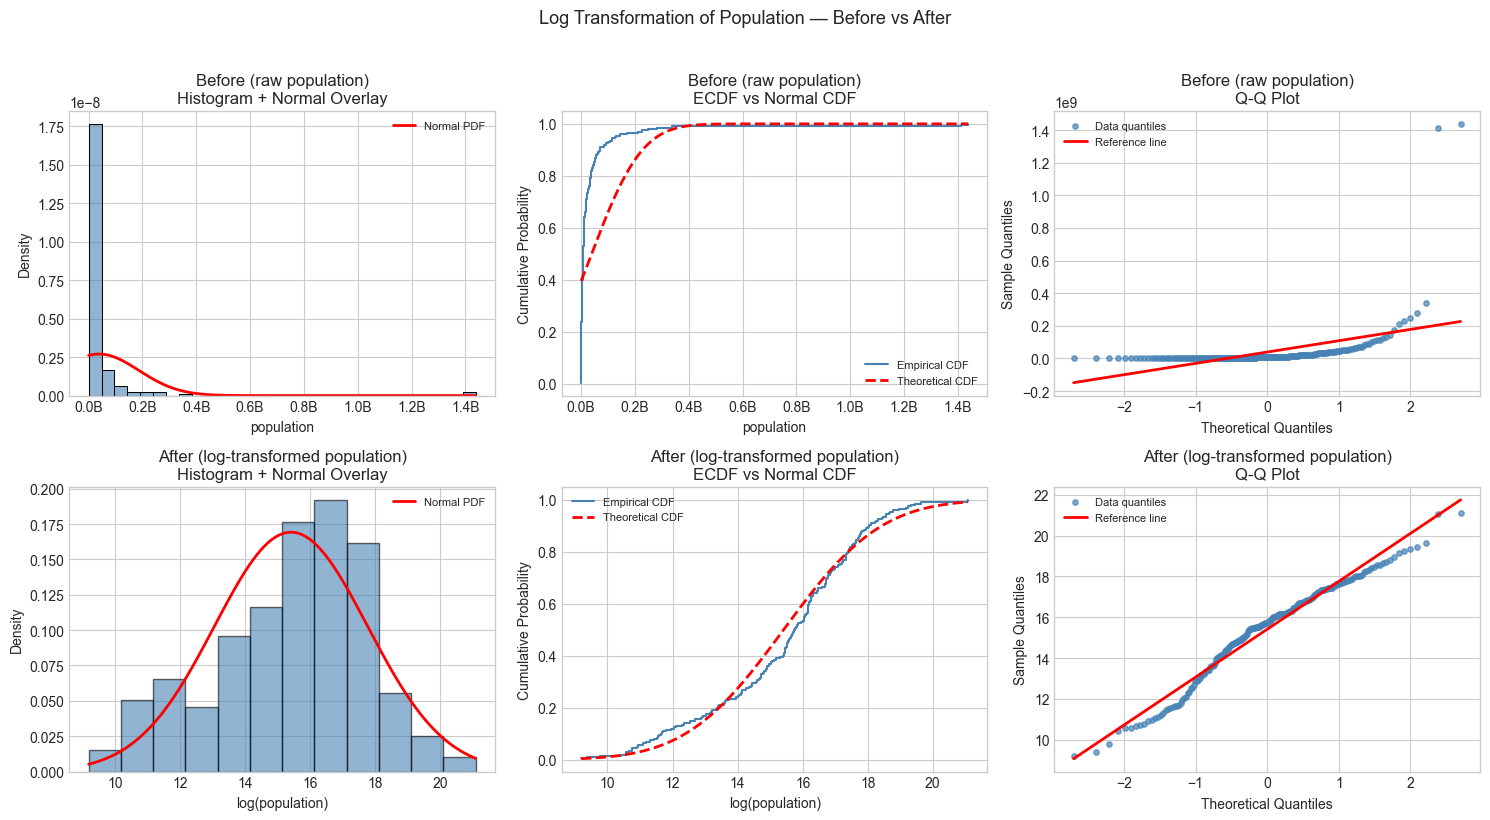

In [127]:
# ── Side-by-side plots: Before vs After Transformation ──
# 2 rows (before / after) × 3 columns (histogram / ECDF / Q-Q)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

datasets = [
    (data_raw, E4_variable, 'Before (raw population)'),
    (data_transformed, transform_name, 'After (log-transformed population)')
]

for row_idx, (data, label, title_prefix) in enumerate(datasets):
    mu_d    = data.mean()
    sigma_d = data.std()
    x_range = np.linspace(data.min(), data.max(), 300)

    # -- Histogram with normal PDF overlay --
    ax = axes[row_idx, 0]
    if row_idx == 0:
        sns.histplot(data, bins=30, kde=False, stat='density',
                     color='steelblue', alpha=0.6, ax=ax)
        ax.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d),
                'r-', lw=2, label='Normal PDF')
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
        )
    else:
        # Log-transformed — standard approach works fine
        ax.hist(data, bins='fd', density=True,
                color='steelblue', alpha=0.6, edgecolor='black')
        ax.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d),
                'r-', lw=2, label='Normal PDF')
    ax.set_title(f'{title_prefix}\nHistogram + Normal Overlay')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # -- Empirical CDF vs Theoretical Normal CDF --
    ax = axes[row_idx, 1]
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.step(sorted_data, ecdf, where='post', color='steelblue', label='Empirical CDF')
    ax.plot(x_range, stats.norm.cdf(x_range, mu_d, sigma_d),
            'r--', lw=2, label='Theoretical CDF')
    ax.set_title(f'{title_prefix}\nECDF vs Normal CDF')
    ax.set_xlabel(label)
    ax.set_ylabel('Cumulative Probability')
    if row_idx == 0:
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
        )
    ax.legend(fontsize=8)

    # -- Q-Q Plot--
    ax = axes[row_idx, 2]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color='steelblue', s=15, alpha=0.7, label='Data quantiles')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Reference line')
    ax.set_title(f'{title_prefix}\nQ-Q Plot')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=8)

plt.suptitle(
    'Log Transformation of Population — Before vs After',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

> **Comparing the before-and-after Q-Q plots**

- Before Transformation, the raw population data exhibits extreme right skewness. The Q-Q plot shows a drastic departure from the red reference line of which the points curve sharply upward at the upper end of the theoretical quantiles. This indicates that a very small number of countries have massive populations compared to the vast majority, creating a "long right tail" that violates the normality assumption.

- After Transformation, the alignment with the reference line is significantly improved. The extreme curvature has been replaced by a much more linear pattern, particularly for the central bulk of the data. While some light-tailed or heavy-tailed behavior may persist at the very extremes (as seen by minor drift at the ends of the Q-Q plot), the log transformation has successfully "squashed" the outliers and transformed the distribution into one that is approximately normal, making it far more suitable for parametric statistical procedures.

In [128]:
# Set the non-normal variable for E4
E4_variable = 'gdp_per_capita'

data_raw = df[E4_variable].dropna()  # Exclude missing values

# Apply log transformation as the variable is strictly positive
data_transformed = np.log(data_raw)
transform_label = 'log'
transform_name = f'log({E4_variable})'

print(f'Variable                    : {E4_variable}')
print('Transformation              : Logarithmic (log)')
print(f'Number of observations (N)  : {len(data_raw)}')

Variable                    : gdp_per_capita
Transformation              : Logarithmic (log)
Number of observations (N)  : 200


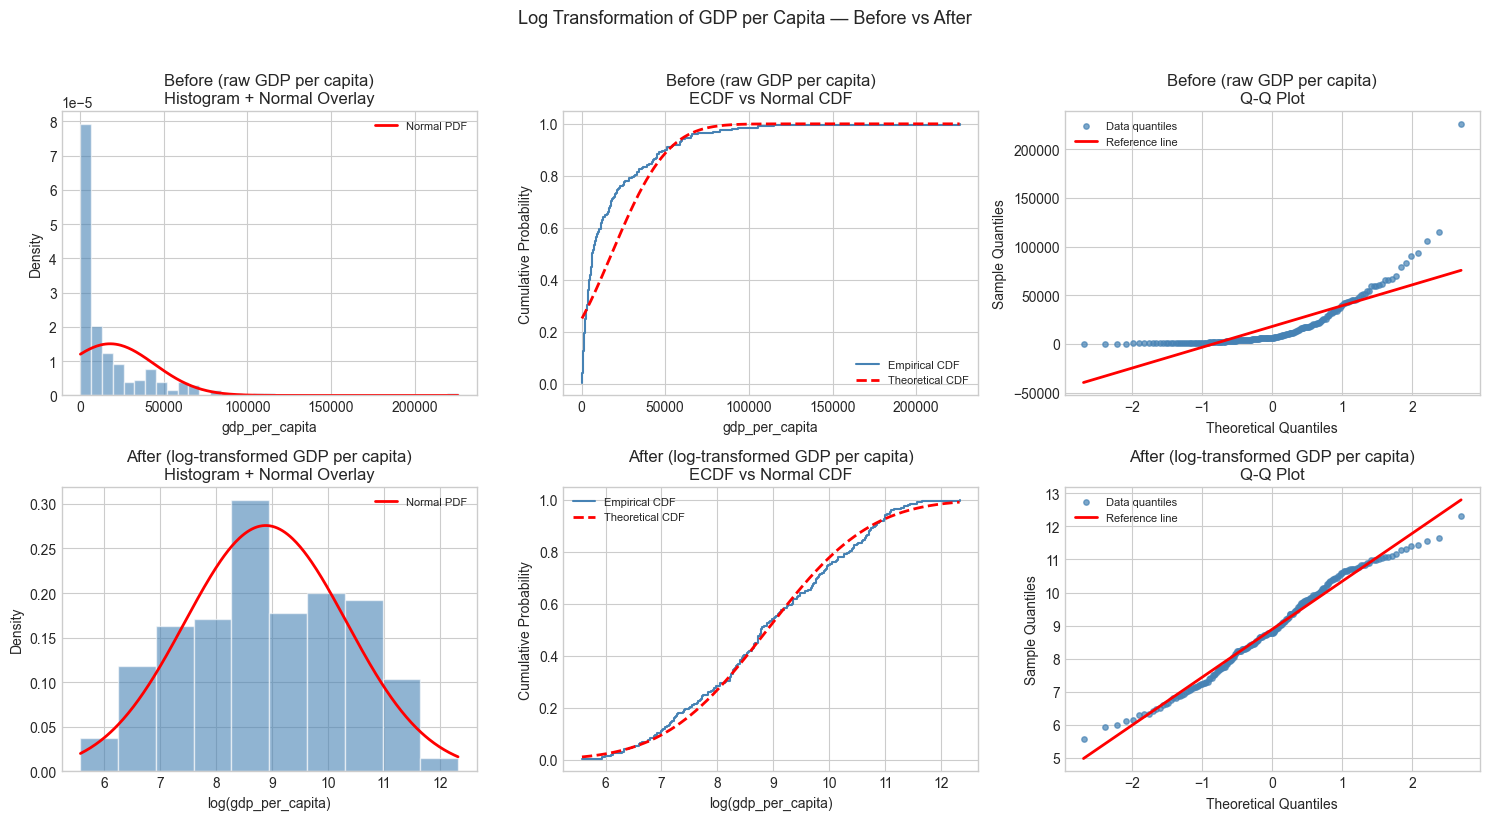

In [129]:
# ── Side-by-side plots: Before vs After Transformation ──
# 2 rows (before / after) × 3 columns (histogram / ECDF / Q-Q)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

datasets = [
    (data_raw, E4_variable, 'Before (raw GDP per capita)'),
    (data_transformed,transform_name, 'After (log-transformed GDP per capita)')
]

for row_idx, (data, label, title_prefix) in enumerate(datasets):
    mu_d    = data.mean()
    sigma_d = data.std()
    x_range = np.linspace(data.min(), data.max(), 300)

    # Histogram with normal PDF overlay
    ax = axes[row_idx, 0]
    ax.hist(data, bins='fd', density=True, color='steelblue', alpha=0.6, edgecolor='white')
    ax.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d), 'r-', lw=2, label='Normal PDF')
    ax.set_title(f'{title_prefix}\nHistogram + Normal Overlay')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # Empirical CDF vs Theoretical Normal CDF
    ax = axes[row_idx, 1]
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.step(sorted_data, ecdf, where='post', color='steelblue', label='Empirical CDF')
    ax.plot(x_range, stats.norm.cdf(x_range, mu_d, sigma_d), 'r--', lw=2, label='Theoretical CDF')
    ax.set_title(f'{title_prefix}\nECDF vs Normal CDF')
    ax.set_xlabel(label)
    ax.set_ylabel('Cumulative Probability')
    ax.legend(fontsize=8)

    # Q-Q Plot
    ax = axes[row_idx, 2]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color='steelblue', s=15, alpha=0.7, label='Data quantiles')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Reference line')
    ax.set_title(f'{title_prefix}\nQ-Q Plot')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Log Transformation of GDP per Capita — Before vs After',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

> **Comparing the before-and-after Q-Q plots**

- Before transformation, the Q-Q plot shows severe deviation from the reference line, with points cluster near zero in the lower tail and curve dramatically upward in the upper tail, showing the classic signature of strong right skew.
- Normality improved substantially after log transformation, points align much more closely to the reference line, particularly in the middle range. Minor deviations remain in both tails — the poorest countries fall slightly below the line at the lower left, and a few ultra-high-income nations drift upward at the upper right — but the extreme curvature of the raw plot is almost entirely eliminated.
- The log transformation successfully reduced skewness and brought GDP per capita to approximate normality. The ECDF aligning closely with the theoretical normal CDF in the bottom row. The histogram also shifts from a heavily right-skewed spike to a bell-shaped distribution centred around log-GDP ≈ 9. While not perfectly normal, the transformed variable is sufficient for parametric statistical analyses.

> **E4. Justification**

1. **Why is the logarithm of a lognormally distributed variable normal?**

A variable $X$ is defined as lognormal if $Y = \ln(X)$ follows a normal distribution. Mathematically, the probability density function (PDF) of a lognormal variable includes a factor of $1/x$, which corresponds to the **Jacobian** of the transformation from the normal variable $Y$ back to $X$.

$$f_X(x) = \frac{1}{x\sigma\sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right)$$

When we apply the natural logarithm transformation, we are effectively reversing this Jacobian. By mapping the multiplicative scale of the original data onto an additive scale, the inherent right-skewness is removed, resulting in a symmetric distribution that follows the Gaussian functional form:
$$f(y) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(y - \mu)^2}{2\sigma^2} \right)$$

2. **What real-world processes generate lognormal data?**

Lognormal distributions arise from **multiplicative processes**, often described by the **Law of Proportional Effect (Gibrat's Law)**. In variables like **population** or **GDP**, growth is not additive but proportional—a country's current size is a product of its previous size multiplied by various growth factors $(1 + r_1)(1 + r_2)...(1 + r_n)$.

Because the product of many independent positive random variables converges to a lognormal distribution (via the Central Limit Theorem applied to the logs of those variables), these socioeconomic metrics naturally exhibit this right-skewed "long-tail" behavior.

3. **How does interpretation change after transformation?**

- **Proportional vs. Absolute Change:** On a raw scale, an increase of 1 million people is negligible for a large nation but massive for a small one. On a log-transformed scale, equal distances represent **equal percentage growth**, allowing for a more consistent comparison across countries of different sizes.
- **Robustness to Outliers:** The arithmetic mean of raw data is heavily skewed by "giants" (e.g., India, China). After log transformation, the mean corresponds to the **geometric mean** of the original data, which is a more stable measure of "typical" size.
- **Variance Stabilization:** Raw socioeconomic data often shows higher absolute volatility as the mean increases. Log transformation "compresses" the scale, reducing heteroscedasticity and creating a more uniform spread (**homoscedasticity**), which is a core requirement for valid parametric statistical models.


# Task F – The Central Limit Theorem and Sample Size Planning
## F1. CLT Demonstration

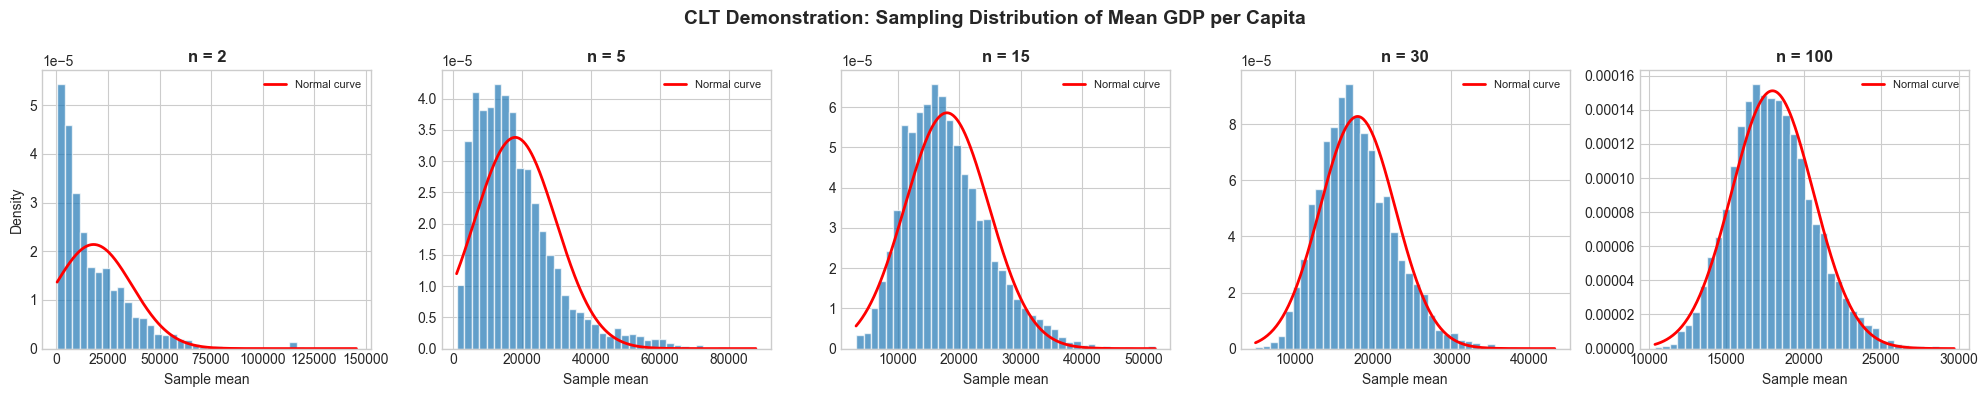


Comparison of Empirical vs Theoretical Sampling Distribution:
  n  Empirical Mean  Theoretical Mean  Empirical SD  Theoretical SD
  2      18,236.130        17,995.980    18,778.030      18,657.920
  5      17,878.780        17,995.980    11,922.530      11,800.310
 15      17,995.890        17,995.980     6,861.660       6,812.910
 30      17,907.210        17,995.980     4,768.830       4,817.450
100      18,018.570        17,995.980     2,648.930       2,638.630

Square Root Law verification (Empirical SD × √n should ≈ Population SD):
n =   2:    18778.03 × √2 =   26556.14  (Population SD = 26386.29)
n =   5:    11922.53 × √5 =   26659.59  (Population SD = 26386.29)
n =  15:     6861.66 × √15 =   26575.09  (Population SD = 26386.29)
n =  30:     4768.83 × √30 =   26119.96  (Population SD = 26386.29)
n = 100:     2648.93 × √100 =   26489.30  (Population SD = 26386.29)


In [130]:
# Population (treat empirical gdp_pc as the population)
population = df["gdp_per_capita"].dropna().values
pop_mean = population.mean()
pop_std  = population.std(ddof=0)   # population std (not sample)

# Settings
sample_sizes = [2, 5, 15, 30, 100]
n_samples    = 5000
np.random.seed(42)

# Plot setup
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
results = []

for i, n in enumerate(sample_sizes):
    # Draw 5000 samples of size n, compute means
    means = np.array([
        np.random.choice(population, size=n, replace=True).mean()
        for _ in range(n_samples)
    ])
    
    # Theoretical values
    theo_mean = pop_mean
    theo_std  = pop_std / np.sqrt(n)
    emp_mean  = means.mean()
    emp_std   = means.std(ddof=0)
    
    results.append({
        "n"               : n,
        "Empirical Mean"  : round(emp_mean, 2),
        "Theoretical Mean": round(theo_mean, 2),
        "Empirical SD"    : round(emp_std, 2),
        "Theoretical SD"  : round(theo_std, 2)
    })
    
    # Histogram
    ax = axes[i]
    ax.hist(means, bins=40, density=True, color="#1f77b4",
            edgecolor="white", alpha=0.7)
    
    # Overlay normal curve
    x_range = np.linspace(means.min(), means.max(), 300)
    ax.plot(x_range, stats.norm.pdf(x_range, theo_mean, theo_std),
            color="red", linewidth=2, label="Normal curve")
    ax.set_title(f"n = {n}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample mean")
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("CLT Demonstration: Sampling Distribution of Mean GDP per Capita",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Comparison table
results_df = pd.DataFrame(results)
print("\nComparison of Empirical vs Theoretical Sampling Distribution:")
print(results_df.to_string(index=False))

# Square Root Law check
print("\nSquare Root Law verification (Empirical SD × √n should ≈ Population SD):")
for r in results:
    check = r["Empirical SD"] * np.sqrt(r["n"])
    print(f"n = {r['n']:>3}:  {r['Empirical SD']:>10.2f} × √{r['n']} = {check:>10.2f}  "
          f"(Population SD = {pop_std:.2f})")

> **F1. Justification**

GDP per capita was chosen as the population because earlier plots already
showed it is heavily right-skewed and far from normal. That makes it the
perfect test case for the Central Limit Theorem. If the CLT can recover
normality from a distribution this skewed, it can do it for almost anything.

**Formal Statement of the Central Limit Theorem**

Given a population with a finite mean μ and a finite standard deviation σ,
the sampling distribution of the sample mean from independent random
samples of size n approaches a normal distribution as n grows large:

$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right) \quad \text{as } n \to \infty$$

What makes this powerful is that it holds no matter what the original
population looks like. Even a strongly skewed variable like GDP per capita
will eventually produce a sampling distribution of means that is roughly
normal, as long as the sample size is large enough.

**What σ/√n Represents**

The expression σ/√n is the standard error of the mean. It measures how
much the sample mean is expected to vary from one random draw to another.
As n grows, √n grows with it, which pulls the standard error down. In
practical terms, larger samples give us more precise estimates of the
true population mean.

**Verification of the Square Root Law**

The Square Root Law says that multiplying the empirical standard deviation
of the sample means by √n should recover the population standard deviation.
The printout above shows this holds well across all five sample sizes,
with values landing close to the population SD. The CLT is not just a
nice idea on paper. It plays out exactly as expected in the numbers.

**When Does the Distribution Look Normal?**

At n = 2 and n = 5 the sampling distribution still carries the skewness of
the original GDP data. By n = 15 the shape begins to settle into something
more symmetric, and by n = 30 it is clearly bell-shaped. At n = 100 the
fit to the theoretical normal curve is almost perfect.

**Is n ≥ 30 Adequate?**

The classic rule of thumb says n ≥ 30 is enough for the CLT to take effect.
For mildly skewed data that is usually true, but for a heavily skewed
variable like GDP per capita, n = 30 gives a sampling distribution that is
approximately normal yet still shows a slight tilt. The rule is a useful
starting point rather than a strict cutoff. The more skewed the population,
the larger the sample size needs to be before the CLT delivers a clean
normal shape.

## F2. Sample Size Planning

Observed proportion: p = 0.3800

Conservative (p = 0.5): n = 1068
Observed (p = 0.38): n = 1006
Difference: 62 fewer samples needed


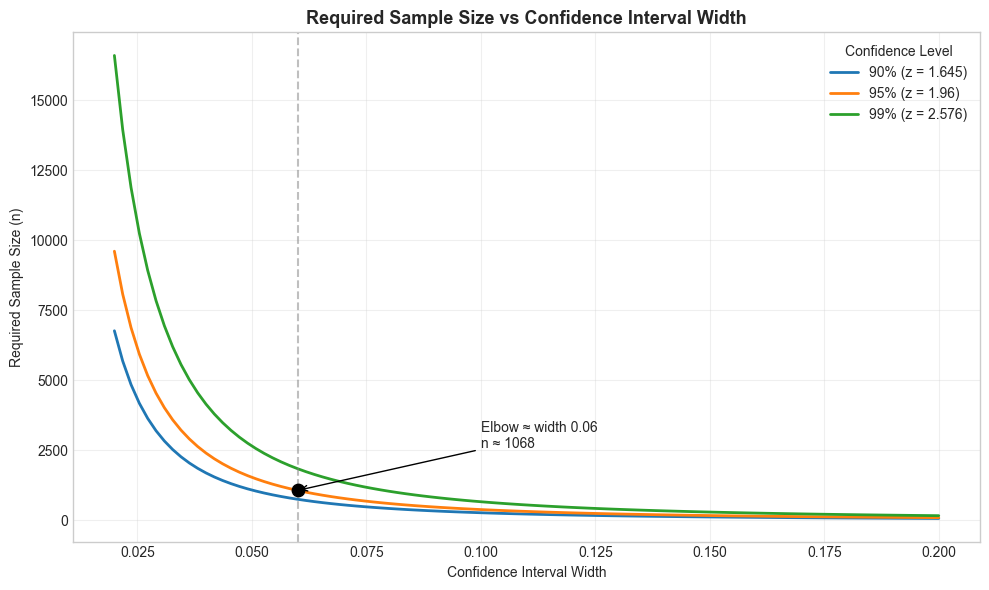

In [131]:
z_95 = 1.96
width = 0.06
margin = width / 2

# Observed proportion (% of high income countries)
p_observed = (df["income_group"] == "High income").mean()
print(f"Observed proportion: p = {p_observed:.4f}")

# Part 1: Conservative bound (p = 0.5)
p = 0.5  
n_conservative = (z_95**2 * p * (1 - p)) / margin**2
n_conservative = int(np.ceil(n_conservative))
print(f"\nConservative (p = 0.5): n = {n_conservative}")

# Part 2: Observed proportion
n_observed = (z_95**2 * p_observed * (1 - p_observed)) / margin**2
n_observed = int(np.ceil(n_observed))
print(f"Observed (p = {p_observed:.2f}): n = {n_observed}")
print(f"Difference: {n_conservative - n_observed} fewer samples needed")

# Part 3: Plot n vs width for 90%, 95%, 99%
widths = np.linspace(0.02, 0.20, 100)
z_values = {"90%": 1.645, "95%": 1.96, "99%": 2.576}

plt.figure(figsize=(10, 6))
for label, z in z_values.items():
    n = (z**2 * 0.5 * 0.5) / (widths / 2)**2
    plt.plot(widths, n, label=f"{label} (z = {z})", linewidth=2)

# Mark the elbow point
elbow_n = (1.96**2 * 0.5 * 0.5) / (0.06 / 2)**2
plt.axvline(0.06, color="grey", linestyle="--", alpha=0.5)
plt.scatter(0.06, elbow_n, color="black", zorder=5, s=80)
plt.annotate(f"Elbow ≈ width 0.06\nn ≈ {int(np.ceil(elbow_n))}",
             xy=(0.06, elbow_n), xytext=(0.10, elbow_n + 1500),
             arrowprops=dict(arrowstyle="->"), fontsize=10)

plt.title("Required Sample Size vs Confidence Interval Width",
          fontsize=13, fontweight="bold")
plt.xlabel("Confidence Interval Width")
plt.ylabel("Required Sample Size (n)")
plt.legend(title="Confidence Level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


> **F2. Justification**

**Where Does the 1.96 Come From?**

The number 1.96 comes from the standard normal distribution (the bell
curve). It is the cutoff value that captures the middle 95% of the data,
with 2.5% left in each tail. Whenever we say we are 95% confident in our
estimate, we are using this exact cutoff. The same idea applies for
other confidence levels: 1.645 is used for 90% confidence, and 2.576
is used for 99% confidence. These three values are exactly what we see
in the plot legend, where each curve represents a different confidence
level using its corresponding z-value.

**Why Sample Size Grows With the Square of 1 / Width**

The formula for finding sample size is:

$$n = \frac{z^2 \cdot p(1-p)}{(w/2)^2}$$

The width sits in the denominator and is squared. This means precision
does not scale linearly. If we want our answer to be twice as accurate,
we need **four times** the sample size. If we want it ten times more
accurate, we need a hundred times more. The plot makes this very clear.
All three curves stay flat on the right side where the width is large,
then bend sharply upward as the width gets smaller. That steep climb
on the left is the squared relationship in action.

**Practical Implication for Halving the Margin of Error**

In our calculation, a sample of **1,068 observations** gives us a 95%
confidence interval that is 0.06 wide (margin of error ±0.03). This is
marked as the elbow point on the plot, where the 95% curve transitions
from flat to steep. If we wanted to halve the margin of error to ±0.015,
the required sample size would jump to about **4,268** which are four times
more for just double the accuracy. This is why the elbow point matters
so much. Past that bend, every small gain in precision costs a lot more
in sample size, time, and money.